# Dissertation Notebook 05

## Final Evaluation and Analysis

**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

This notebook evaluates the diagnosis-only Swin-Tiny baseline, the full multi-task Swin-Tiny model and the leave-one-out auxiliary-task ablations.

Saved ISIC validation and test predictions are used for the main diagnostic analyses, operating points and calibration. Saved Derm7pt auxiliary metrics are used for the auxiliary-head evaluation, while the selected checkpoints are used for Derm7pt diagnostic and PH2 inference.

No model training or checkpoint selection is performed in this notebook.

## Setup

Imports and project paths used for the final evaluation are defined here.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

import timm
from PIL import Image

import sklearn
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"timm        : {timm.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Device      : {DEVICE}")
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print(f"Device      : {DEVICE}")

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
timm        : 1.0.29
scikit-learn: 1.6.1
pandas      : 2.2.3
numpy       : 2.1.3
matplotlib  : 3.10.0
Device      : cuda
GPU         : NVIDIA L4


## Project paths

Saved baseline, multi-task and ablation artefacts are read from Google Drive.

Notebook 05 saves its evaluation tables, figures and prediction files in a separate evaluation directory.

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
print("Google Drive mounted")


Mounted at /content/drive
Google Drive mounted


In [3]:
## Project paths

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation_Data")


## ISIC 2019

ISIC_ROOT = PROJECT_ROOT / "ISIC2019"
ISIC_SPLIT_DIR = ISIC_ROOT / "splits"


## Derm7pt

DERM7PT_ROOT = PROJECT_ROOT / "Derm7pt"
DERM7PT_DATA_DIR = DERM7PT_ROOT / "release_v0"
DERM7PT_META_DIR = DERM7PT_DATA_DIR / "meta"
DERM7PT_IMAGE_DIR = DERM7PT_DATA_DIR / "images"

DERM7PT_META_CSV = DERM7PT_META_DIR / "meta.csv"
DERM7PT_TEST_INDEXES = DERM7PT_META_DIR / "test_indexes.csv"
DERM7PT_TARGETS_CSV = DERM7PT_ROOT / "audit_outputs" / "derm7pt_encoded_targets.csv"


## PH2

PH2_BASE = PROJECT_ROOT / "PH2"
PH2_ROOT = PH2_BASE / "archive" / "PH2Dataset"
PH2_IMAGE_DIR = PH2_ROOT / "PH2 Dataset images"


## Baseline outputs

BASELINE_ROOT = PROJECT_ROOT / "Baseline"
BASELINE_CHECKPOINT_DIR = BASELINE_ROOT / "checkpoints"
BASELINE_RESULTS_DIR = BASELINE_ROOT / "results"
BASELINE_PREDICTION_DIR = BASELINE_ROOT / "predictions"


## Multi-task outputs

MTL_ROOT = PROJECT_ROOT / "MultiTask"
MTL_CHECKPOINT_DIR = MTL_ROOT / "checkpoints"
MTL_RESULTS_DIR = MTL_ROOT / "results"
MTL_PREDICTION_DIR = MTL_ROOT / "predictions"
MTL_AUXILIARY_DIR = MTL_ROOT / "auxiliary_results"


## Notebook 05 outputs

EVALUATION_ROOT = PROJECT_ROOT / "FinalEvaluation_Folder"
EVALUATION_TABLE_DIR = EVALUATION_ROOT / "tables"
EVALUATION_FIGURE_DIR = EVALUATION_ROOT / "figures"
EVALUATION_PREDICTION_DIR = EVALUATION_ROOT / "predictions"


for directory in [
    EVALUATION_TABLE_DIR,
    EVALUATION_FIGURE_DIR,
    EVALUATION_PREDICTION_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


print("=" * 67)
print(f"{'Project paths':^67}")
print("=" * 67, "\n")

print(f"ISIC 2019  : {ISIC_ROOT}")
print(f"Derm7pt    : {DERM7PT_ROOT}")
print(f"PH2        : {PH2_ROOT}")
print(f"Baseline   : {BASELINE_ROOT}")
print(f"Multi-task : {MTL_ROOT}")
print(f"Evaluation : {EVALUATION_ROOT}")

                           Project paths                           

ISIC 2019  : /content/drive/MyDrive/Dissertation_Data/ISIC2019
Derm7pt    : /content/drive/MyDrive/Dissertation_Data/Derm7pt
PH2        : /content/drive/MyDrive/Dissertation_Data/PH2/archive/PH2Dataset
Baseline   : /content/drive/MyDrive/Dissertation_Data/Baseline
Multi-task : /content/drive/MyDrive/Dissertation_Data/MultiTask
Evaluation : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder


## Section 1: Define the experiment registry

The experiment registry identifies the saved baseline, full multi-task and leave-one-out ablation runs used by this notebook.

Run names and file locations are defined in one place so that the evaluation code does not depend on hard-coded paths elsewhere in the notebook.

### 1.1 Define the evaluated runs

The main comparison uses baseline and full multi-task runs from seeds 41, 42 and 43.

The leave-one-out auxiliary-task ablations use seed 42.


In [4]:
## Define the evaluated runs

FINAL_TRAIN_SEEDS = (41, 42, 43)
ABLATION_SEED = 42

AUX_TASKS = (
    "pigment_network",
    "blue_whitish_veil",
    "vascular_structures",
    "pigmentation",
    "streaks",
    "dots_and_globules",
    "regression_structures",
)

BASELINE_RUN_NAMES = {
    41: "baseline_final_v2_seed_41",
    42: "baseline_final_v2_seed_42",
    43: "baseline_final_v2_seed_43",
}

MTL_RUN_NAMES = {
    41: "mtl_final_v2_seed_41",
    42: "mtl_final_v2_seed_42",
    43: "mtl_final_v2_seed_43",
}

ABLATION_RUN_NAMES = {
    task_name: f"mtl_ablation_v2_no_{task_name}_seed_{ABLATION_SEED}"
    for task_name in AUX_TASKS
}


print("=" * 67)
print(f"{'Evaluated runs':^67}")
print("=" * 67, "\n")

print(f"Baseline runs : {len(BASELINE_RUN_NAMES)}")
print(f"Full MTL runs : {len(MTL_RUN_NAMES)}")
print(f"Ablation runs : {len(ABLATION_RUN_NAMES)}")


                          Evaluated runs                           

Baseline runs : 3
Full MTL runs : 3
Ablation runs : 7


### 1.2 Build the file registry

Each run is linked to the saved files required by the final evaluation.

All runs retain their summaries and saved ISIC validation and test predictions. The baseline and full multi-task runs also retain their selected checkpoints for later diagnostic inference.

The full multi-task runs additionally retain the saved Derm7pt auxiliary metrics used in Section 9.

In [5]:
## Build the file registry

baseline_registry = {}

for seed, run_name in BASELINE_RUN_NAMES.items():

    baseline_registry[seed] = {
        "experiment_type": "Baseline",
        "run_name": run_name,
        "training_seed": seed,
        "checkpoint_file": BASELINE_CHECKPOINT_DIR / f"{run_name}_best.pt",
        "summary_file": BASELINE_RESULTS_DIR / f"{run_name}_summary.json",
        "validation_predictions": BASELINE_PREDICTION_DIR / f"{run_name}_validation_predictions.csv",
        "test_predictions": BASELINE_PREDICTION_DIR / f"{run_name}_test_predictions.csv",
    }


mtl_registry = {}

for seed, run_name in MTL_RUN_NAMES.items():

    mtl_registry[seed] = {
        "experiment_type": "Full MTL",
        "run_name": run_name,
        "training_seed": seed,
        "checkpoint_file": MTL_CHECKPOINT_DIR / f"{run_name}_best.pt",
        "summary_file": MTL_RESULTS_DIR / f"{run_name}_summary.json",
        "validation_predictions": MTL_PREDICTION_DIR / f"{run_name}_validation_predictions.csv",
        "test_predictions": MTL_PREDICTION_DIR / f"{run_name}_test_predictions.csv",
        "derm7pt_auxiliary_metrics": MTL_AUXILIARY_DIR / f"{run_name}_derm7pt_auxiliary_metrics.json",
    }


ablation_registry = {}

for task_name, run_name in ABLATION_RUN_NAMES.items():

    ablation_registry[task_name] = {
        "experiment_type": "Ablation",
        "run_name": run_name,
        "training_seed": ABLATION_SEED,
        "removed_task": task_name,
        "summary_file": MTL_RESULTS_DIR / f"{run_name}_summary.json",
        "validation_predictions": MTL_PREDICTION_DIR / f"{run_name}_validation_predictions.csv",
        "test_predictions": MTL_PREDICTION_DIR / f"{run_name}_test_predictions.csv",
    }


print("=" * 67)
print(f"{'Experiment registry':^67}")
print("=" * 67, "\n")

print(f"Baseline runs : {len(baseline_registry)}")
print(f"Full MTL runs : {len(mtl_registry)}")
print(f"Ablation runs : {len(ablation_registry)}")

                        Experiment registry                        

Baseline runs : 3
Full MTL runs : 3
Ablation runs : 7


### 1.3 Review the registered experiments

The table below gives a quick overview of the runs used in the final evaluation.

The baseline and full multi-task models use seeds 41, 42 and 43. The leave-one-out ablations use seed 42.

In [6]:
## Build a compact registry overview

registry_rows = []

for seed, run_info in baseline_registry.items():

    registry_rows.append({
        "Model": "Baseline",
        "Seed": seed,
        "Auxiliary tasks": "None",
        "Use": "Main comparison",
        "Run name": run_info["run_name"],
    })


for seed, run_info in mtl_registry.items():

    registry_rows.append({
        "Model": "Full MTL",
        "Seed": seed,
        "Auxiliary tasks": "All 7 tasks",
        "Use": "Main comparison",
        "Run name": run_info["run_name"],
    })


for task_name, run_info in ablation_registry.items():

    registry_rows.append({
        "Model": "LOO ablation",
        "Seed": run_info["training_seed"],
        "Auxiliary tasks": f"Without {task_name}",
        "Use": "Ablation check",
        "Run name": run_info["run_name"],
    })


registry_overview_df = pd.DataFrame(registry_rows)


print("=" * 67)
print(f"{'Registered experiments':^67}")
print("=" * 67, "\n")

display(registry_overview_df)

                      Registered experiments                       



,Model,Seed,Auxiliary tasks,Use,Run name
0,Baseline,41,None,Main comparison,baseline_final_v2_seed_41
1,Baseline,42,None,Main comparison,baseline_final_v2_seed_42
2,Baseline,43,None,Main comparison,baseline_final_v2_seed_43
3,Full MTL,41,All 7 tasks,Main comparison,mtl_final_v2_seed_41
4,Full MTL,42,All 7 tasks,Main comparison,mtl_final_v2_seed_42
5,Full MTL,43,All 7 tasks,Main comparison,mtl_final_v2_seed_43
6,LOO ablation,42,Without pigment_network,Ablation check,mtl_ablation_v2_no_pigment_network_seed_42
7,LOO ablation,42,Without blue_whitish_veil,Ablation check,mtl_ablation_v2_no_blue_whitish_veil_seed_42
8,LOO ablation,42,Without vascular_structures,Ablation check,mtl_ablation_v2_no_vascular_structures_seed_42
9,LOO ablation,42,Without pigmentation,Ablation check,mtl_ablation_v2_no_pigmentation_seed_42


## Section 2: Load and check the saved outputs

The fixed ISIC splits and saved model outputs are loaded here.

Basic checks are carried out before calculating the final evaluation metrics.


### 2.1 Load the fixed ISIC splits

The train, validation and test files saved in Notebook 02 are loaded directly.

The image IDs are checked for duplicates and overlap between the three splits.


In [7]:
## Load the fixed ISIC splits

isic_train_df = pd.read_csv(ISIC_SPLIT_DIR / "train.csv")
isic_validation_df = pd.read_csv(ISIC_SPLIT_DIR / "validation.csv")
isic_test_df = pd.read_csv(ISIC_SPLIT_DIR / "test.csv")


split_dataframes = {
    "Train": isic_train_df,
    "Validation": isic_validation_df,
    "Test": isic_test_df,
}

split_rows = []

for split_name, dataframe in split_dataframes.items():

    if dataframe["isic_id"].isna().any():
        raise ValueError(f"{split_name}: missing isic_id values.")

    if dataframe["isic_id"].duplicated().any():
        raise ValueError(f"{split_name}: duplicate isic_id values.")

    split_rows.append({
        "Split": split_name,
        "Images": len(dataframe),
        "Unique IDs": dataframe["isic_id"].nunique(),
    })


train_ids = set(isic_train_df["isic_id"])
validation_ids = set(isic_validation_df["isic_id"])
test_ids = set(isic_test_df["isic_id"])

if train_ids & validation_ids:
    raise ValueError("Train and validation IDs overlap.")

if train_ids & test_ids:
    raise ValueError("Train and test IDs overlap.")

if validation_ids & test_ids:
    raise ValueError("Validation and test IDs overlap.")


split_summary_df = pd.DataFrame(split_rows)


print("=" * 67)
print(f"{'Fixed ISIC splits':^67}")
print("=" * 67, "\n")

display(split_summary_df)

print("No image ID overlap found between splits.")

                         Fixed ISIC splits                         



,Split,Images,Unique IDs
0,Train,17672,17672
1,Validation,3808,3808
2,Test,3851,3851


No image ID overlap found between splits.


### 2.2 Check the registered files

The files listed in the experiment registry are checked before they are loaded.

A missing file stops the evaluation.

In [8]:
## Check the registered files

file_check_rows = []


def check_registry_files(registry):

    for _, run_info in registry.items():

        path_items = {
            name: value
            for name, value in run_info.items()
            if isinstance(value, Path)
        }

        missing_files = [
            name for name, path in path_items.items() if not path.exists()
        ]

        file_check_rows.append({
            "Model": run_info["experiment_type"],
            "Seed": run_info["training_seed"],
            "Run name": run_info["run_name"],
            "Files checked": len(path_items),
            "Missing": len(missing_files),
        })

        if missing_files:
            print(f"\nMissing files for {run_info['run_name']}:")

            for name in missing_files:
                print(f"- {name}: {path_items[name]}")


check_registry_files(baseline_registry)
check_registry_files(mtl_registry)
check_registry_files(ablation_registry)

file_check_df = pd.DataFrame(file_check_rows)


print("=" * 67)
print(f"{'Saved file check':^67}")
print("=" * 67, "\n")

display(file_check_df)

if file_check_df["Missing"].sum() > 0:
    raise FileNotFoundError("One or more registered files are missing.")

print("All registered files were found.")

                         Saved file check                          



,Model,Seed,Run name,Files checked,Missing
0,Baseline,41,baseline_final_v2_seed_41,4,0
1,Baseline,42,baseline_final_v2_seed_42,4,0
2,Baseline,43,baseline_final_v2_seed_43,4,0
3,Full MTL,41,mtl_final_v2_seed_41,5,0
4,Full MTL,42,mtl_final_v2_seed_42,5,0
5,Full MTL,43,mtl_final_v2_seed_43,5,0
6,Ablation,42,mtl_ablation_v2_no_pigment_network_seed_42,3,0
7,Ablation,42,mtl_ablation_v2_no_blue_whitish_veil_seed_42,3,0
8,Ablation,42,mtl_ablation_v2_no_vascular_structures_seed_42,3,0
9,Ablation,42,mtl_ablation_v2_no_pigmentation_seed_42,3,0


All registered files were found.


### 2.3 Load the saved model outputs

The run summaries and saved ISIC prediction tables are loaded for each experiment.

The saved predictions are used for the main evaluation without rerunning the models.

In [9]:
## Load saved summaries and prediction tables

def load_json(path):

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def load_run_outputs(registry):

    summaries = {}
    predictions = {}

    for run_key, run_info in registry.items():

        summaries[run_key] = load_json(run_info["summary_file"])

        predictions[run_key] = {
            "validation": pd.read_csv(run_info["validation_predictions"]),
            "test": pd.read_csv(run_info["test_predictions"]),
        }

    return summaries, predictions


baseline_summaries, baseline_predictions = load_run_outputs(baseline_registry)
mtl_summaries, mtl_predictions = load_run_outputs(mtl_registry)
ablation_summaries, ablation_predictions = load_run_outputs(ablation_registry)


loaded_outputs_df = pd.DataFrame([
    {"Model": "Baseline", "Runs": len(baseline_summaries)},
    {"Model": "Full MTL", "Runs": len(mtl_summaries)},
    {"Model": "LOO ablation", "Runs": len(ablation_summaries)},
])


print("=" * 67)
print(f"{'Saved outputs loaded':^67}")
print("=" * 67, "\n")

display(loaded_outputs_df)

                       Saved outputs loaded                        



,Model,Runs
0,Baseline,3
1,Full MTL,3
2,LOO ablation,7


### 2.4 Check the saved run details and predictions

The saved run name, seed and diagnostic target are checked against the registry.

The validation and test prediction files are also checked for valid labels and probabilities.



In [10]:
## Check run details and saved predictions

CLASS_NAMES = ["Benign", "Indeterminate", "Malignant"]

CLASS_TO_IDX = {
    "Benign": 0,
    "Indeterminate": 1,
    "Malignant": 2,
}

IDX_TO_CLASS = {value: key for key, value in CLASS_TO_IDX.items()}

PROBABILITY_COLUMNS = ["P_Benign", "P_Indeterminate", "P_Malignant"]

REQUIRED_COLUMNS = [
    "isic_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "true_label",
    "true_class",
    "predicted_label",
    "predicted_class",
    "P_Benign",
    "P_Indeterminate",
    "P_Malignant",
    "training_seed",
    "run_name",
    "split",
]


prediction_check_rows = []


def check_prediction_table(dataframe, run_name, seed, split_name):

    missing_columns = [
        column for column in REQUIRED_COLUMNS if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{run_name} / {split_name}: missing columns {missing_columns}."
        )

    if dataframe["isic_id"].isna().any():
        raise ValueError(f"{run_name} / {split_name}: missing image IDs.")

    if dataframe["isic_id"].duplicated().any():
        raise ValueError(f"{run_name} / {split_name}: duplicate image IDs.")

    if set(dataframe["run_name"]) != {run_name}:
        raise ValueError(f"{run_name} / {split_name}: run name does not match.")

    if set(dataframe["training_seed"].astype(int)) != {seed}:
        raise ValueError(f"{run_name} / {split_name}: training seed does not match.")

    if set(dataframe["split"]) != {split_name}:
        raise ValueError(f"{run_name} / {split_name}: split name does not match.")


    expected_true_classes = np.array(
        [IDX_TO_CLASS[int(label)] for label in dataframe["true_label"]]
    )

    if not np.array_equal(
        expected_true_classes,
        dataframe["true_class"].astype(str).to_numpy(),
    ):
        raise ValueError(f"{run_name} / {split_name}: true labels do not match.")


    if not np.array_equal(
        dataframe["diagnosis_1"].astype(str).to_numpy(),
        dataframe["true_class"].astype(str).to_numpy(),
    ):
        raise ValueError(
            f"{run_name} / {split_name}: diagnosis_1 does not match "
            "the saved true class."
        )


    probabilities = dataframe[PROBABILITY_COLUMNS].to_numpy(dtype=float)

    if not np.isfinite(probabilities).all():
        raise ValueError(
            f"{run_name} / {split_name}: non-finite probabilities found."
        )

    if (probabilities < 0).any() or (probabilities > 1).any():
        raise ValueError(
            f"{run_name} / {split_name}: probabilities outside [0, 1]."
        )

    if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(
            f"{run_name} / {split_name}: probabilities do not sum to 1."
        )


    predicted_labels = dataframe["predicted_label"].astype(int).to_numpy()

    if not np.array_equal(probabilities.argmax(axis=1), predicted_labels):
        raise ValueError(
            f"{run_name} / {split_name}: predicted labels do not match "
            "the probability argmax."
        )


    expected_predicted_classes = np.array(
        [IDX_TO_CLASS[int(label)] for label in predicted_labels]
    )

    if not np.array_equal(
        expected_predicted_classes,
        dataframe["predicted_class"].astype(str).to_numpy(),
    ):
        raise ValueError(
            f"{run_name} / {split_name}: predicted classes do not match."
        )


def check_saved_run(run_info, summary, prediction_tables):

    run_name = run_info["run_name"]
    seed = int(run_info["training_seed"])

    if summary["run_name"] != run_name:
        raise ValueError(f"{run_name}: run name does not match the summary.")

    if int(summary["training_seed"]) != seed:
        raise ValueError(f"{run_name}: training seed does not match the summary.")

    if summary["primary_target"] != "diagnosis_1":
        raise ValueError(f"{run_name}: unexpected primary target.")

    if summary["class_to_idx"] != CLASS_TO_IDX:
        raise ValueError(f"{run_name}: class mapping does not match.")


    for split_name in ["validation", "test"]:

        check_prediction_table(
            dataframe=prediction_tables[split_name],
            run_name=run_name,
            seed=seed,
            split_name=split_name,
        )


    prediction_check_rows.append({
        "Model": run_info["experiment_type"],
        "Seed": seed,
        "Removed task": run_info.get("removed_task", "-"),
        "Validation": len(prediction_tables["validation"]),
        "Test": len(prediction_tables["test"]),
        "Status": "OK",
    })


for seed in baseline_registry:
    check_saved_run(
        baseline_registry[seed],
        baseline_summaries[seed],
        baseline_predictions[seed],
    )


for seed in mtl_registry:
    check_saved_run(
        mtl_registry[seed],
        mtl_summaries[seed],
        mtl_predictions[seed],
    )


for task_name in ablation_registry:
    check_saved_run(
        ablation_registry[task_name],
        ablation_summaries[task_name],
        ablation_predictions[task_name],
    )


prediction_check_df = pd.DataFrame(prediction_check_rows)


print("=" * 67)
print(f"{'Prediction checks':^67}")
print("=" * 67, "\n")

display(prediction_check_df)

                         Prediction checks                         



,Model,Seed,Removed task,Validation,Test,Status
0,Baseline,41,-,3808,3851,OK
1,Baseline,42,-,3808,3851,OK
2,Baseline,43,-,3808,3851,OK
3,Full MTL,41,-,3808,3851,OK
4,Full MTL,42,-,3808,3851,OK
5,Full MTL,43,-,3808,3851,OK
6,Ablation,42,pigment_network,3808,3851,OK
7,Ablation,42,blue_whitish_veil,3808,3851,OK
8,Ablation,42,vascular_structures,3808,3851,OK
9,Ablation,42,pigmentation,3808,3851,OK


### 2.5 Match the predictions to the fixed ISIC splits

The validation and test predictions are matched back to the fixed split files using `isic_id`.

The diagnostic labels must agree with the original split metadata before the results are used.

In [11]:
## Match predictions to the fixed ISIC splits

TRUTH_COLUMNS = ["diagnosis_1", "diagnosis_2", "diagnosis_3"]

fixed_evaluation_splits = {
    "validation": isic_validation_df,
    "test": isic_test_df,
}

alignment_rows = []


def normalise_truth_table(dataframe):

    output = dataframe[["isic_id", *TRUTH_COLUMNS]].copy()
    output["isic_id"] = output["isic_id"].astype(str)

    for column in TRUTH_COLUMNS:
        output[column] = output[column].fillna("<NA>").astype(str)

    return output.sort_values("isic_id").reset_index(drop=True)


def check_split_alignment(run_info, prediction_tables):

    for split_name, fixed_df in fixed_evaluation_splits.items():

        prediction_df = prediction_tables[split_name]

        fixed_truth = normalise_truth_table(fixed_df)
        prediction_truth = normalise_truth_table(prediction_df)

        if not fixed_truth.equals(prediction_truth):
            raise ValueError(
                f"{run_info['run_name']} / {split_name}: predictions do "
                "not match the fixed ISIC split."
            )

        alignment_rows.append({
            "Model": run_info["experiment_type"],
            "Seed": run_info["training_seed"],
            "Split": split_name.capitalize(),
            "Images": len(prediction_truth),
            "Status": "OK",
        })


for seed in baseline_registry:
    check_split_alignment(baseline_registry[seed], baseline_predictions[seed])

for seed in mtl_registry:
    check_split_alignment(mtl_registry[seed], mtl_predictions[seed])

for task_name in ablation_registry:
    check_split_alignment(
        ablation_registry[task_name],
        ablation_predictions[task_name],
    )


alignment_check_df = pd.DataFrame(alignment_rows)

alignment_summary_df = (
    alignment_check_df
    .groupby(["Model", "Split"], as_index=False)
    .agg(
        Runs=("Status", "size"),
        Images=("Images", "first"),
        Passed=("Status", lambda values: (values == "OK").sum()),
    )
)


print("=" * 67)
print(f"{'ISIC split alignment':^67}")
print("=" * 67, "\n")

display(alignment_summary_df)

print("All saved predictions match the fixed ISIC splits.")

                       ISIC split alignment                        



,Model,Split,Runs,Images,Passed
0,Ablation,Test,7,3851,7
1,Ablation,Validation,7,3808,7
2,Baseline,Test,3,3851,3
3,Baseline,Validation,3,3808,3
4,Full MTL,Test,3,3851,3
5,Full MTL,Validation,3,3808,3


All saved predictions match the fixed ISIC splits.


### 2.6 Recalculate balanced accuracy

Balanced accuracy is recalculated from the saved validation and test predictions.

The values are checked against the results saved by the training notebooks.

In [12]:
## Recalculate balanced accuracy

ba_check_rows = []


def check_balanced_accuracy(run_info, summary, prediction_tables):

    summary_keys = {
        "validation": "reloaded_validation_balanced_accuracy",
        "test": "test_balanced_accuracy_run_level",
    }

    for split_name, summary_key in summary_keys.items():

        dataframe = prediction_tables[split_name]

        recalculated_ba = balanced_accuracy_score(
            dataframe["true_label"], dataframe["predicted_label"]
        )

        saved_ba = float(summary[summary_key])
        difference = abs(recalculated_ba - saved_ba)

        if not np.isclose(recalculated_ba, saved_ba, atol=1e-10):
            raise ValueError(
                f"{run_info['run_name']} / {split_name}: balanced accuracy "
                "does not match."
            )

        ba_check_rows.append({
            "Model": run_info["experiment_type"],
            "Seed": run_info["training_seed"],
            "Removed task": run_info.get("removed_task", "-"),
            "Split": split_name.capitalize(),
            "Saved BA": saved_ba,
            "Recalculated BA": recalculated_ba,
            "Difference": difference,
        })


for seed in baseline_registry:
    check_balanced_accuracy(
        baseline_registry[seed],
        baseline_summaries[seed],
        baseline_predictions[seed],
    )


for seed in mtl_registry:
    check_balanced_accuracy(
        mtl_registry[seed],
        mtl_summaries[seed],
        mtl_predictions[seed],
    )


for task_name in ablation_registry:
    check_balanced_accuracy(
        ablation_registry[task_name],
        ablation_summaries[task_name],
        ablation_predictions[task_name],
    )


ba_check_df = pd.DataFrame(ba_check_rows)


print("=" * 67)
print(f"{'Balanced accuracy check':^67}")
print("=" * 67, "\n")

display(
    ba_check_df.round({
        "Saved BA": 4,
        "Recalculated BA": 4,
        "Difference": 12,
    })
)

print("All balanced accuracy values match.")

                      Balanced accuracy check                      



,Model,Seed,Removed task,Split,Saved BA,Recalculated BA,Difference
0,Baseline,41,-,Validation,0.6910,0.6910,0.0
1,Baseline,41,-,Test,0.7020,0.7020,0.0
2,Baseline,42,-,Validation,0.6816,0.6816,0.0
3,Baseline,42,-,Test,0.6938,0.6938,0.0
4,Baseline,43,-,Validation,0.7023,0.7023,0.0
5,Baseline,43,-,Test,0.7323,0.7323,0.0
6,Full MTL,41,-,Validation,0.6765,0.6765,0.0
7,Full MTL,41,-,Test,0.6903,0.6903,0.0
8,Full MTL,42,-,Validation,0.6800,0.6800,0.0
9,Full MTL,42,-,Test,0.7214,0.7214,0.0


All balanced accuracy values match.


**Observation:** The saved model outputs passed the file, prediction, split-alignment and balanced accuracy checks.

## Section 3: ISIC three-class results

The main diagnosis task is evaluated on the held-out ISIC test split.

Results are reported for Benign, Indeterminate and Malignant across the three baseline and full multi-task seeds.

### 3.1 Main test metrics

Balanced accuracy, macro precision, macro recall, macro F1 and one-vs-rest macro AUROC are calculated for each seed.

Macro recall is expected to match balanced accuracy because both average recall across the three diagnostic classes.


In [13]:
## Calculate the main three-class metrics

three_class_rows = []
three_class_class_rows = []


def calculate_three_class_metrics(model_name, seed, dataframe):

    y_true = dataframe["true_label"].astype(int).to_numpy()
    y_pred = dataframe["predicted_label"].astype(int).to_numpy()
    probabilities = dataframe[PROBABILITY_COLUMNS].to_numpy(dtype=float)

    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    class_precision, class_recall, class_f1, class_support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )

    class_aurocs = []

    for class_index, class_name in enumerate(CLASS_NAMES):

        binary_truth = (y_true == class_index).astype(int)
        class_auroc = roc_auc_score(binary_truth, probabilities[:, class_index])

        class_aurocs.append(class_auroc)

        three_class_class_rows.append({
            "Model": model_name,
            "Seed": seed,
            "Class": class_name,
            "Precision": class_precision[class_index],
            "Recall": class_recall[class_index],
            "F1": class_f1[class_index],
            "Support": int(class_support[class_index]),
            "AUROC": class_auroc,
        })

    three_class_rows.append({
        "Model": model_name,
        "Seed": seed,
        "Balanced accuracy": balanced_accuracy,
        "Macro precision": macro_precision,
        "Macro recall": macro_recall,
        "Macro F1": macro_f1,
        "Macro AUROC": np.mean(class_aurocs),
    })


for seed in FINAL_TRAIN_SEEDS:

    calculate_three_class_metrics(
        model_name="Baseline",
        seed=seed,
        dataframe=baseline_predictions[seed]["test"],
    )

    calculate_three_class_metrics(
        model_name="Full MTL",
        seed=seed,
        dataframe=mtl_predictions[seed]["test"],
    )


three_class_run_df = pd.DataFrame(three_class_rows)
three_class_class_df = pd.DataFrame(three_class_class_rows)


print("=" * 67)
print(f"{'ISIC three-class test results':^67}")
print("=" * 67, "\n")

display(three_class_run_df.round(4))

                   ISIC three-class test results                   



,Model,Seed,Balanced accuracy,Macro precision,Macro recall,Macro F1,Macro AUROC
0,Baseline,41,0.7020,0.6382,0.7020,0.6602,0.9076
1,Full MTL,41,0.6903,0.6173,0.6903,0.6411,0.9010
2,Baseline,42,0.6938,0.6389,0.6938,0.6594,0.9021
3,Full MTL,42,0.7214,0.6324,0.7214,0.6602,0.9071
4,Baseline,43,0.7323,0.5876,0.7323,0.5935,0.8911
5,Full MTL,43,0.6868,0.6242,0.6868,0.6382,0.9047


### 3.2 Results across the three seeds

The baseline and full multi-task results are summarised using the mean and sample standard deviation across seeds 41, 42 and 43.


In [14]:
## Summarise the three main seeds

SUMMARY_METRICS = [
    "Balanced accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Macro AUROC",
]

summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_results = three_class_run_df[
        three_class_run_df["Model"] == model_name
    ]

    summary_row = {"Model": model_name}

    for metric in SUMMARY_METRICS:

        mean_value = model_results[metric].mean()
        sd_value = model_results[metric].std(ddof=1)

        summary_row[metric] = f"{mean_value:.4f} ± {sd_value:.4f}"

    summary_rows.append(summary_row)


three_class_summary_df = pd.DataFrame(summary_rows)


print("=" * 67)
print(f"{'Three-seed summary':^67}")
print("=" * 67, "\n")

display(three_class_summary_df)

                        Three-seed summary                         



,Model,Balanced accuracy,Macro precision,Macro recall,Macro F1,Macro AUROC
0,Baseline,0.7094 ± 0.0203,0.6216 ± 0.0294,0.7094 ± 0.0203,0.6377 ± 0.0383,0.9003 ± 0.0084
1,Full MTL,0.6995 ± 0.0190,0.6246 ± 0.0076,0.6995 ± 0.0190,0.6465 ± 0.0120,0.9043 ± 0.0031


### 3.3 Results by diagnostic class

Precision, recall, F1 and one-vs-rest AUROC are summarised separately for Benign, Indeterminate and Malignant.

The support is the number of test images in each class.

In [15]:
## Summarise results by diagnostic class

class_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    for class_name in CLASS_NAMES:

        class_results = three_class_class_df[
            (three_class_class_df["Model"] == model_name)
            & (three_class_class_df["Class"] == class_name)
        ]

        class_summary_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Support": int(class_results["Support"].iloc[0]),
            "Precision": (
                f"{class_results['Precision'].mean():.4f} ± "
                f"{class_results['Precision'].std(ddof=1):.4f}"
            ),
            "Recall": (
                f"{class_results['Recall'].mean():.4f} ± "
                f"{class_results['Recall'].std(ddof=1):.4f}"
            ),
            "F1": (
                f"{class_results['F1'].mean():.4f} ± "
                f"{class_results['F1'].std(ddof=1):.4f}"
            ),
            "AUROC": (
                f"{class_results['AUROC'].mean():.4f} ± "
                f"{class_results['AUROC'].std(ddof=1):.4f}"
            ),
        })


three_class_per_class_summary_df = pd.DataFrame(class_summary_rows)


print("=" * 67)
print(f"{'Per-class test results':^67}")
print("=" * 67, "\n")

display(three_class_per_class_summary_df)

                      Per-class test results                       



,Model,Class,Support,Precision,Recall,F1,AUROC
0,Baseline,Benign,2404,0.8999 ± 0.0056,0.7852 ± 0.0223,0.8385 ± 0.0102,0.9071 ± 0.0031
1,Baseline,Indeterminate,130,0.2854 ± 0.0923,0.6051 ± 0.1632,0.3691 ± 0.0676,0.9227 ± 0.0102
2,Baseline,Malignant,1317,0.6795 ± 0.0151,0.7378 ± 0.0892,0.7056 ± 0.0427,0.8711 ± 0.0223
3,Full MTL,Benign,2404,0.8824 ± 0.0193,0.8156 ± 0.0560,0.8466 ± 0.0215,0.9048 ± 0.0081
4,Full MTL,Indeterminate,130,0.2958 ± 0.0317,0.5590 ± 0.0424,0.3865 ± 0.0356,0.9311 ± 0.0054
5,Full MTL,Malignant,1317,0.6958 ± 0.0457,0.7239 ± 0.0715,0.7063 ± 0.0140,0.8769 ± 0.0041


### 3.4 Confusion matrices

Normalised confusion matrices are shown for each of the three baseline and full multi-task runs.

Each row represents the true diagnostic class.

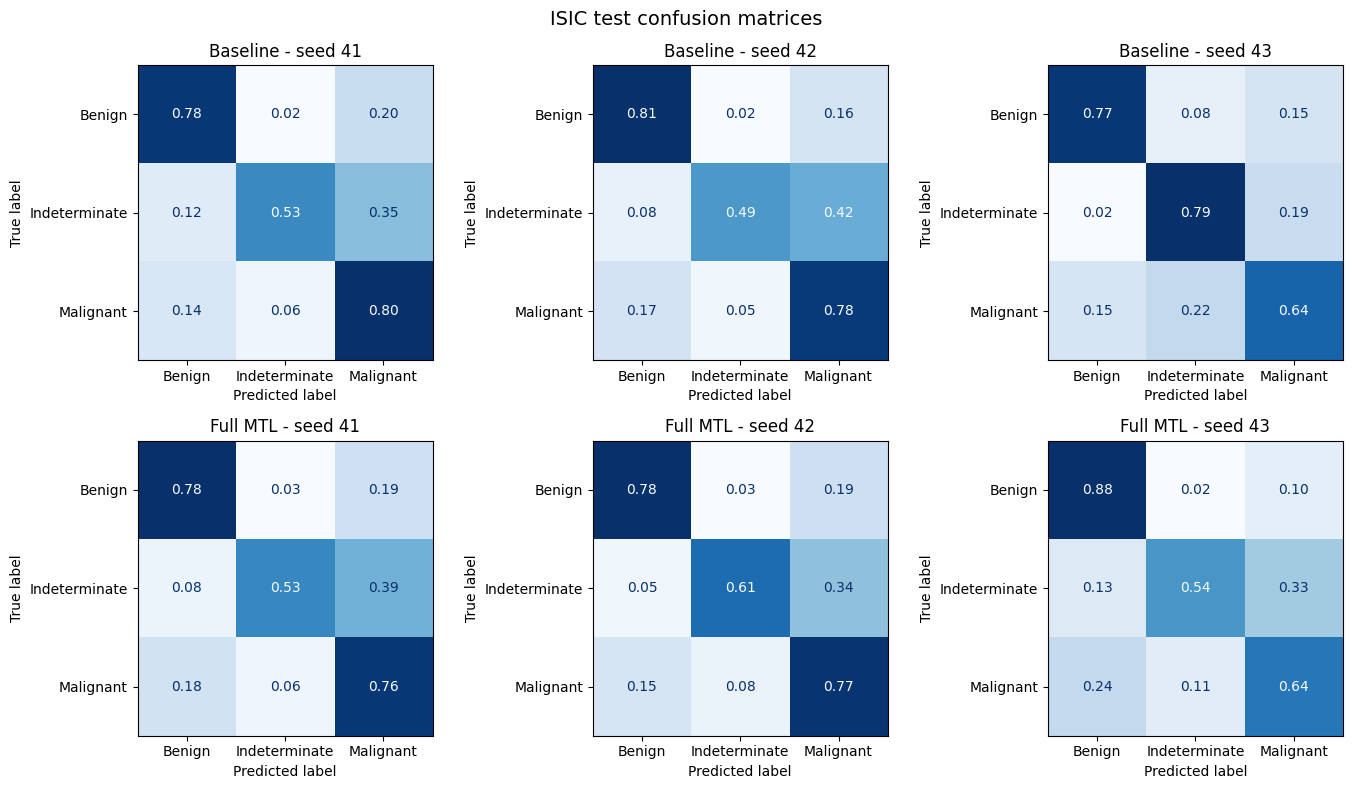

In [16]:
## Plot normalised confusion matrices

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

model_sets = [
    ("Baseline", baseline_predictions),
    ("Full MTL", mtl_predictions),
]


for row_index, (model_name, prediction_set) in enumerate(model_sets):

    for column_index, seed in enumerate(FINAL_TRAIN_SEEDS):

        dataframe = prediction_set[seed]["test"]

        confusion = confusion_matrix(
            dataframe["true_label"],
            dataframe["predicted_label"],
            labels=[0, 1, 2],
            normalize="true",
        )

        display_matrix = ConfusionMatrixDisplay(
            confusion_matrix=confusion,
            display_labels=CLASS_NAMES,
        )

        display_matrix.plot(
            ax=axes[row_index, column_index],
            cmap="Blues",
            colorbar=False,
            values_format=".2f",
        )

        axes[row_index, column_index].set_title(
            f"{model_name} - seed {seed}"
        )


fig.suptitle("ISIC test confusion matrices", fontsize=14)

plt.tight_layout()

CONFUSION_FIGURE_PATH = (
    EVALUATION_FIGURE_DIR / "isic_three_class_confusion_matrices.png"
)

plt.savefig(
    CONFUSION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Section 4: Malignant vs rest

A binary malignant-versus-rest analysis is carried out using the saved `P_Malignant` score.

Malignant cases are the positive class. Benign and Indeterminate cases are kept together as the negative class.

The probability threshold is selected on the validation split and then applied unchanged to the test split.

### 4.1 Define the binary target

The binary target is created from `diagnosis_1`.

The full ROC curve and AUROC are calculated for each baseline and full multi-task seed.

In [17]:
## Malignant-versus-rest setup

SENSITIVITY_TARGETS = [0.90, 0.95]


def get_malignant_binary_data(dataframe):

    y_true = (
        dataframe["diagnosis_1"]
        .eq("Malignant")
        .astype(int)
        .to_numpy()
    )

    scores = dataframe["P_Malignant"].astype(float).to_numpy()

    return y_true, scores

### 4.2 Select the operating points

For each target sensitivity, the threshold is selected using the validation split.

Among thresholds reaching at least the target sensitivity, the threshold with the highest specificity is selected. If more than one threshold gives the same specificity, the highest threshold is used.

The selected threshold is then applied unchanged to the test split.

In [18]:
## Functions for the sensitivity operating points

def select_sensitivity_threshold(y_true, scores, target_sensitivity):

    fpr, tpr, thresholds = roc_curve(y_true, scores)

    eligible = np.where(tpr >= target_sensitivity)[0]

    if len(eligible) == 0:
        raise ValueError("No threshold reached the requested sensitivity.")

    best_fpr = fpr[eligible].min()

    best_candidates = eligible[
        np.isclose(fpr[eligible], best_fpr)
    ]

    best_index = best_candidates[
        np.argmax(thresholds[best_candidates])
    ]

    return {
        "threshold": float(thresholds[best_index]),
        "sensitivity": float(tpr[best_index]),
        "specificity": float(1.0 - fpr[best_index]),
    }


def apply_binary_threshold(y_true, scores, threshold):

    predictions = (scores >= threshold).astype(int)

    true_positive = np.sum(
        (y_true == 1) & (predictions == 1)
    )

    false_negative = np.sum(
        (y_true == 1) & (predictions == 0)
    )

    true_negative = np.sum(
        (y_true == 0) & (predictions == 0)
    )

    false_positive = np.sum(
        (y_true == 0) & (predictions == 1)
    )

    sensitivity = true_positive / (true_positive + false_negative)
    specificity = true_negative / (true_negative + false_positive)

    return {
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "false_positive_rate": float(1.0 - specificity),
    }

### 4.3 Calculate the malignant-versus-rest results

AUROC is calculated separately on the validation and test splits.

The 90% and 95% sensitivity thresholds come only from validation data.

In [19]:
## Calculate malignant-versus-rest results

malignant_auc_rows = []
malignant_operating_rows = []


def evaluate_malignant_run(model_name, seed, prediction_tables):

    validation_df = prediction_tables["validation"]
    test_df = prediction_tables["test"]

    validation_truth, validation_scores = get_malignant_binary_data(
        validation_df
    )

    test_truth, test_scores = get_malignant_binary_data(test_df)

    validation_auc = roc_auc_score(
        validation_truth,
        validation_scores,
    )

    test_auc = roc_auc_score(
        test_truth,
        test_scores,
    )

    malignant_auc_rows.append({
        "Model": model_name,
        "Seed": seed,
        "Validation AUROC": validation_auc,
        "Test AUROC": test_auc,
        "Test positives": int(test_truth.sum()),
        "Test negatives": int((test_truth == 0).sum()),
    })


    for target in SENSITIVITY_TARGETS:

        validation_point = select_sensitivity_threshold(
            validation_truth,
            validation_scores,
            target,
        )

        test_point = apply_binary_threshold(
            test_truth,
            test_scores,
            validation_point["threshold"],
        )

        malignant_operating_rows.append({
            "Model": model_name,
            "Seed": seed,
            "Target sensitivity": target,
            "Threshold": validation_point["threshold"],
            "Validation sensitivity": validation_point["sensitivity"],
            "Validation specificity": validation_point["specificity"],
            "Test sensitivity": test_point["sensitivity"],
            "Test specificity": test_point["specificity"],
            "Test FPR": test_point["false_positive_rate"],
        })


for seed in FINAL_TRAIN_SEEDS:

    evaluate_malignant_run(
        model_name="Baseline",
        seed=seed,
        prediction_tables=baseline_predictions[seed],
    )

    evaluate_malignant_run(
        model_name="Full MTL",
        seed=seed,
        prediction_tables=mtl_predictions[seed],
    )


malignant_auc_df = pd.DataFrame(malignant_auc_rows)
malignant_operating_df = pd.DataFrame(malignant_operating_rows)


### 4.4 Malignant-versus-rest AUROC

The table shows the continuous malignant-versus-rest discrimination for each seed.

The score is the model's broad `P_Malignant` output.

In [20]:
## Display malignant-versus-rest AUROC

print("=" * 67)
print(f"{'Malignant vs rest AUROC':^67}")
print("=" * 67, "\n")

display(
    malignant_auc_df.round({
        "Validation AUROC": 4,
        "Test AUROC": 4,
    })
)


                      Malignant vs rest AUROC                      



,Model,Seed,Validation AUROC,Test AUROC,Test positives,Test negatives
0,Baseline,41,0.8700,0.8818,1317,2534
1,Full MTL,41,0.8716,0.8724,1317,2534
2,Baseline,42,0.8873,0.8860,1317,2534
3,Full MTL,42,0.8729,0.8779,1317,2534
4,Baseline,43,0.8315,0.8454,1317,2534
5,Full MTL,43,0.8717,0.8804,1317,2534


### 4.5 Three-seed AUROC summary

Test AUROC is summarised using the mean and sample standard deviation across seeds 41, 42 and 43.

In [21]:
## Summarise test AUROC across seeds

malignant_auc_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_results = malignant_auc_df[
        malignant_auc_df["Model"] == model_name
    ]

    malignant_auc_summary_rows.append({
        "Model": model_name,
        "Test AUROC": (
            f"{model_results['Test AUROC'].mean():.4f} ± "
            f"{model_results['Test AUROC'].std(ddof=1):.4f}"
        ),
    })


malignant_auc_summary_df = pd.DataFrame(
    malignant_auc_summary_rows
)


print("=" * 67)
print(f"{'Three-seed AUROC summary':^67}")
print("=" * 67, "\n")

display(malignant_auc_summary_df)

                     Three-seed AUROC summary                      



,Model,Test AUROC
0,Baseline,0.8711 ± 0.0223
1,Full MTL,0.8769 ± 0.0041


### 4.6 Sensitivity operating points

For each model and seed, a probability threshold is selected on the validation split to achieve at least 90% sensitivity and at least 95% sensitivity.

The selected threshold is then applied unchanged to the held-out test split. The threshold is a cutoff on the broad `P_Malignant` score, not a percentage sensitivity value.

In [22]:
## Display validation-selected sensitivity operating points

malignant_operating_wide_rows = []

for model_name in ["Baseline", "Full MTL"]:

    for seed in FINAL_TRAIN_SEEDS:

        run_results = malignant_operating_df[
            (malignant_operating_df["Model"] == model_name)
            & (malignant_operating_df["Seed"] == seed)
        ]

        point_90 = run_results[
            np.isclose(run_results["Target sensitivity"], 0.90)
        ].iloc[0]

        point_95 = run_results[
            np.isclose(run_results["Target sensitivity"], 0.95)
        ].iloc[0]

        malignant_operating_wide_rows.append({
            "Model": model_name,
            "Seed": seed,
            "Threshold for >=90% val sensitivity": point_90["Threshold"],
            "90% target: val sensitivity": point_90["Validation sensitivity"],
            "90% target: val specificity": point_90["Validation specificity"],
            "90% target: test sensitivity": point_90["Test sensitivity"],
            "90% target: test specificity": point_90["Test specificity"],
            "Threshold for >=95% val sensitivity": point_95["Threshold"],
            "95% target: val sensitivity": point_95["Validation sensitivity"],
            "95% target: val specificity": point_95["Validation specificity"],
            "95% target: test sensitivity": point_95["Test sensitivity"],
            "95% target: test specificity": point_95["Test specificity"],
        })


malignant_operating_wide_df = pd.DataFrame(
    malignant_operating_wide_rows
)


print("=" * 67)
print(f"{'Malignant vs rest operating points':^67}")
print("=" * 67, "\n")

display(malignant_operating_wide_df.round(4))

                Malignant vs rest operating points                 



,Model,Seed,Threshold for >=90% val sensitivity,90% target: val sensitivity,90% target: val specificity,90% target: test sensitivity,90% target: test specificity,Threshold for >=95% val sensitivity,95% target: val sensitivity,95% target: val specificity,95% target: test sensitivity,95% target: test specificity
0,Baseline,41,0.2116,0.9007,0.6232,0.8975,0.6251,0.1233,0.9507,0.5326,0.9431,0.5276
1,Baseline,42,0.1302,0.9015,0.6805,0.8952,0.6748,0.0350,0.9507,0.5188,0.9560,0.5182
2,Baseline,43,0.1653,0.9007,0.5666,0.8960,0.5588,0.1130,0.9515,0.4599,0.9453,0.4558
3,Full MTL,41,0.2793,0.9015,0.6477,0.9021,0.6452,0.1945,0.9507,0.5453,0.9400,0.5383
4,Full MTL,42,0.2563,0.9015,0.6564,0.8990,0.6342,0.1789,0.9507,0.5611,0.9423,0.5489
5,Full MTL,43,0.1691,0.9007,0.6631,0.8891,0.6800,0.0900,0.9507,0.5457,0.9499,0.5300


### 4.7 Test ROC curves

The held-out test ROC curves are shown for the three baseline and full multi-task seeds.

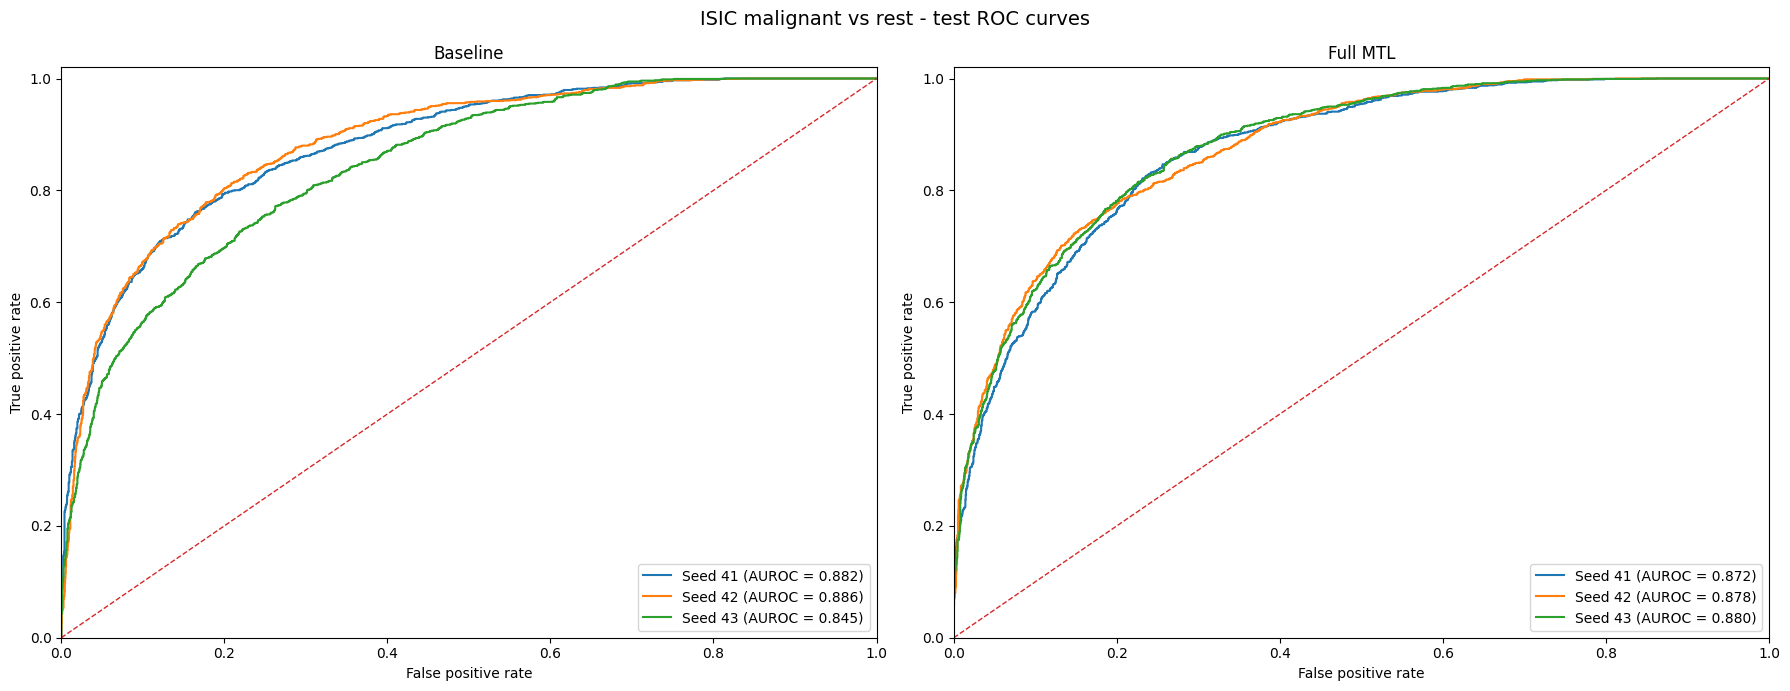

In [23]:
## Plot malignant-versus-rest test ROC curves

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_sets = [
    ("Baseline", baseline_predictions),
    ("Full MTL", mtl_predictions),
]


for axis, (model_name, prediction_set) in zip(axes, model_sets):

    for seed in FINAL_TRAIN_SEEDS:

        test_df = prediction_set[seed]["test"]

        y_true, scores = get_malignant_binary_data(test_df)

        fpr, tpr, _ = roc_curve(y_true, scores)
        test_auc = roc_auc_score(y_true, scores)

        axis.plot(
            fpr,
            tpr,
            label=f"Seed {seed} (AUROC = {test_auc:.3f})",
        )


    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(model_name)
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.legend(loc="lower right")


fig.suptitle(
    "ISIC malignant vs rest - test ROC curves",
    fontsize=14,
)

plt.tight_layout()

MALIGNANT_ROC_FIGURE_PATH = (
    EVALUATION_FIGURE_DIR / "isic_malignant_vs_rest_roc.png"
)

plt.savefig(
    MALIGNANT_ROC_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Section 5: Melanoma vs rest

A binary melanoma-versus-rest analysis is derived from the more detailed `diagnosis_2` metadata.

Melanoma cases are the positive class and all other cases are the negative class. The score remains the model's broad `P_Malignant` output.

The model was not trained to separate melanoma from other malignant diagnoses such as BCC or SCC. `P_Malignant` is therefore treated as a broad malignancy score rather than a melanoma-specific probability.


### 5.1 Check the melanoma target

The exact melanoma category from `diagnosis_2` is used to define the positive class.

The label and class hierarchy are checked before the binary evaluation is calculated.

In [24]:
## Check the melanoma target

MELANOMA_LABEL = "Malignant melanocytic proliferations (Melanoma)"

melanoma_target_rows = []

for split_name, dataframe in fixed_evaluation_splits.items():

    if dataframe["diagnosis_2"].isna().any():
        raise ValueError(f"{split_name}: diagnosis_2 contains missing values.")

    if MELANOMA_LABEL not in set(dataframe["diagnosis_2"].astype(str)):
        raise ValueError(f"{split_name}: melanoma label was not found.")

    melanoma_mask = dataframe["diagnosis_2"].eq(MELANOMA_LABEL)

    melanoma_primary_labels = set(
        dataframe.loc[melanoma_mask, "diagnosis_1"]
    )

    if melanoma_primary_labels != {"Malignant"}:
        raise ValueError(
            f"{split_name}: melanoma cases do not all map to "
            "Malignant in diagnosis_1."
        )

    melanoma_target_rows.append({
        "Split": split_name.capitalize(),
        "Melanoma": int(melanoma_mask.sum()),
        "Non-melanoma": int((~melanoma_mask).sum()),
        "Total": len(dataframe),
    })


melanoma_target_df = pd.DataFrame(melanoma_target_rows)


print("=" * 67)
print(f"{'Melanoma target check':^67}")
print("=" * 67, "\n")

print(f"Positive class : {MELANOMA_LABEL}")
print("Negative class : all other diagnosis_2 categories")
print("Score          : P_Malignant")
print()

display(melanoma_target_df)

print("All melanoma cases map to diagnosis_1 = Malignant.")

                       Melanoma target check                       

Positive class : Malignant melanocytic proliferations (Melanoma)
Negative class : all other diagnosis_2 categories
Score          : P_Malignant



,Split,Melanoma,Non-melanoma,Total
0,Validation,686,3122,3808
1,Test,692,3159,3851


All melanoma cases map to diagnosis_1 = Malignant.


### 5.2 Prepare the binary data

Melanoma is coded as positive and every other `diagnosis_2` category is coded as negative.

The saved `P_Malignant` probability is used as the score.

In [25]:
## Prepare melanoma-versus-rest data

def get_melanoma_binary_data(dataframe):

    y_true = (
        dataframe["diagnosis_2"]
        .eq(MELANOMA_LABEL)
        .astype(int)
        .to_numpy()
    )

    scores = dataframe["P_Malignant"].astype(float).to_numpy()

    return y_true, scores

### 5.3 Calculate the melanoma-versus-rest results

AUROC is calculated on the validation and test splits.

The 90% and 95% sensitivity thresholds are selected from the validation split and then applied unchanged to the held-out test split.

In [26]:
## Calculate melanoma-versus-rest results

melanoma_auc_rows = []
melanoma_operating_rows = []


def evaluate_melanoma_run(model_name, seed, prediction_tables):

    validation_df = prediction_tables["validation"]
    test_df = prediction_tables["test"]

    validation_truth, validation_scores = get_melanoma_binary_data(
        validation_df
    )

    test_truth, test_scores = get_melanoma_binary_data(test_df)

    validation_auc = roc_auc_score(
        validation_truth,
        validation_scores,
    )

    test_auc = roc_auc_score(
        test_truth,
        test_scores,
    )

    melanoma_auc_rows.append({
        "Model": model_name,
        "Seed": seed,
        "Validation AUROC": validation_auc,
        "Test AUROC": test_auc,
        "Test melanoma": int(test_truth.sum()),
        "Test non-melanoma": int((test_truth == 0).sum()),
    })


    for target in SENSITIVITY_TARGETS:

        validation_point = select_sensitivity_threshold(
            validation_truth,
            validation_scores,
            target,
        )

        test_point = apply_binary_threshold(
            test_truth,
            test_scores,
            validation_point["threshold"],
        )

        melanoma_operating_rows.append({
            "Model": model_name,
            "Seed": seed,
            "Target sensitivity": target,
            "Threshold": validation_point["threshold"],
            "Validation sensitivity": validation_point["sensitivity"],
            "Validation specificity": validation_point["specificity"],
            "Test sensitivity": test_point["sensitivity"],
            "Test specificity": test_point["specificity"],
            "Test FPR": test_point["false_positive_rate"],
        })


for seed in FINAL_TRAIN_SEEDS:

    evaluate_melanoma_run(
        model_name="Baseline",
        seed=seed,
        prediction_tables=baseline_predictions[seed],
    )

    evaluate_melanoma_run(
        model_name="Full MTL",
        seed=seed,
        prediction_tables=mtl_predictions[seed],
    )


melanoma_auc_df = pd.DataFrame(melanoma_auc_rows)
melanoma_operating_df = pd.DataFrame(melanoma_operating_rows)

### 5.4 Melanoma-versus-rest AUROC

The table reports melanoma-versus-rest discrimination for each seed.

`P_Malignant` remains a broad malignancy score and is not interpreted as a melanoma probability.

In [27]:
## Display melanoma-versus-rest AUROC

print("=" * 67)
print(f"{'Melanoma vs rest AUROC':^67}")
print("=" * 67, "\n")

display(
    melanoma_auc_df.round({
        "Validation AUROC": 4,
        "Test AUROC": 4,
    })
)


                      Melanoma vs rest AUROC                       



,Model,Seed,Validation AUROC,Test AUROC,Test melanoma,Test non-melanoma
0,Baseline,41,0.7916,0.7994,692,3159
1,Full MTL,41,0.7851,0.7747,692,3159
2,Baseline,42,0.7701,0.7731,692,3159
3,Full MTL,42,0.8135,0.8057,692,3159
4,Baseline,43,0.7804,0.7933,692,3159
5,Full MTL,43,0.7796,0.7770,692,3159


### 5.5 Three-seed AUROC summary

Test AUROC is summarised using the mean and sample standard deviation across seeds 41, 42 and 43.

In [28]:
## Summarise melanoma test AUROC

melanoma_auc_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_results = melanoma_auc_df[
        melanoma_auc_df["Model"] == model_name
    ]

    mean_auc = model_results["Test AUROC"].mean()
    sd_auc = model_results["Test AUROC"].std(ddof=1)

    melanoma_auc_summary_rows.append({
        "Model": model_name,
        "Test AUROC": f"{mean_auc:.4f} ± {sd_auc:.4f}",
    })


melanoma_auc_summary_df = pd.DataFrame(
    melanoma_auc_summary_rows
)


print("=" * 67)
print(f"{'Three-seed AUROC summary':^67}")
print("=" * 67, "\n")

display(melanoma_auc_summary_df)


                     Three-seed AUROC summary                      



,Model,Test AUROC
0,Baseline,0.7886 ± 0.0138
1,Full MTL,0.7858 ± 0.0173


### 5.6 Sensitivity operating points

For each model and seed, a probability threshold is selected on the validation split to achieve at least 90% sensitivity and at least 95% sensitivity.

The selected threshold is then applied unchanged to the test split. The threshold is a cutoff on the broad `P_Malignant` score, not a percentage sensitivity value.

In [29]:
## Display validation-selected sensitivity operating points

melanoma_operating_wide_rows = []

for model_name in ["Baseline", "Full MTL"]:

    for seed in FINAL_TRAIN_SEEDS:

        run_results = melanoma_operating_df[
            (melanoma_operating_df["Model"] == model_name)
            & (melanoma_operating_df["Seed"] == seed)
        ]

        point_90 = run_results[
            np.isclose(run_results["Target sensitivity"], 0.90)
        ].iloc[0]

        point_95 = run_results[
            np.isclose(run_results["Target sensitivity"], 0.95)
        ].iloc[0]

        melanoma_operating_wide_rows.append({
            "Model": model_name,
            "Seed": seed,
            "Threshold for >=90% val sensitivity": point_90["Threshold"],
            "90% target: val sensitivity": point_90["Validation sensitivity"],
            "90% target: val specificity": point_90["Validation specificity"],
            "90% target: test sensitivity": point_90["Test sensitivity"],
            "90% target: test specificity": point_90["Test specificity"],
            "Threshold for >=95% val sensitivity": point_95["Threshold"],
            "95% target: val sensitivity": point_95["Validation sensitivity"],
            "95% target: val specificity": point_95["Validation specificity"],
            "95% target: test sensitivity": point_95["Test sensitivity"],
            "95% target: test specificity": point_95["Test specificity"],
        })


melanoma_operating_wide_df = pd.DataFrame(
    melanoma_operating_wide_rows
)


print("=" * 67)
print(f"{'Melanoma vs rest operating points':^67}")
print("=" * 67, "\n")

display(melanoma_operating_wide_df.round(4))

                 Melanoma vs rest operating points                 



,Model,Seed,Threshold for >=90% val sensitivity,90% target: val sensitivity,90% target: val specificity,90% target: test sensitivity,90% target: test specificity,Threshold for >=95% val sensitivity,95% target: val sensitivity,95% target: val specificity,95% target: test sensitivity,95% target: test specificity
0,Baseline,41,0.1847,0.9009,0.4997,0.9118,0.4983,0.1165,0.9504,0.4318,0.9465,0.4274
1,Baseline,42,0.0711,0.9009,0.5010,0.9277,0.4948,0.0275,0.9504,0.4049,0.9653,0.4023
2,Baseline,43,0.1637,0.9009,0.4750,0.9032,0.4676,0.1062,0.9504,0.3655,0.9509,0.3634
3,Full MTL,41,0.2152,0.9009,0.4680,0.8801,0.4596,0.1474,0.9504,0.3850,0.9350,0.3827
4,Full MTL,42,0.2555,0.9009,0.5490,0.8757,0.5233,0.1536,0.9504,0.4302,0.9451,0.4185
5,Full MTL,43,0.1131,0.9009,0.4811,0.8931,0.4777,0.0653,0.9504,0.3876,0.9509,0.3811


### 5.7 Test ROC curves

The held-out test ROC curves are shown for the three baseline and full multi-task seeds.

The curves use the broad `P_Malignant` score against the melanoma-versus-rest target.

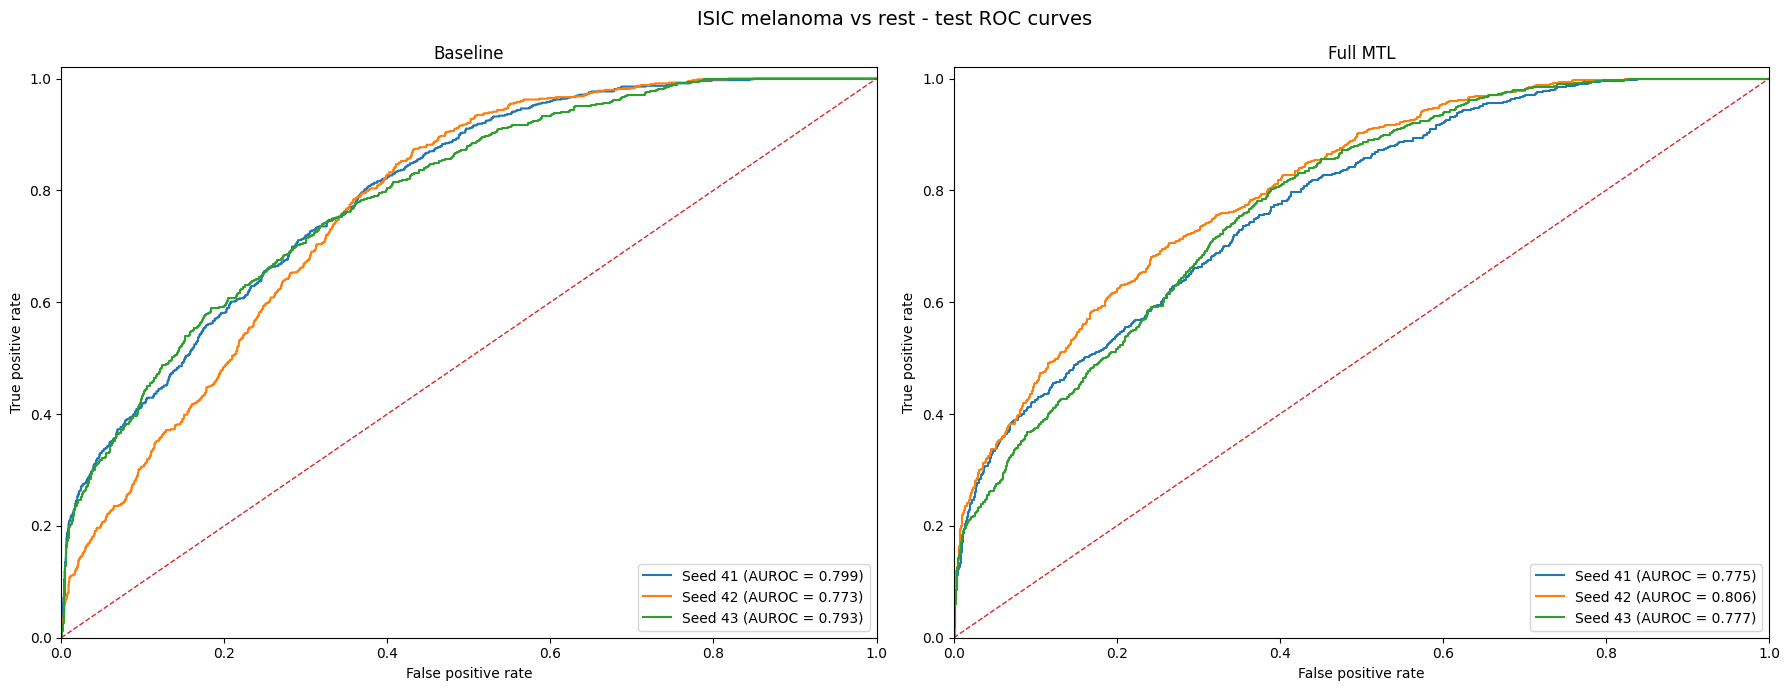

In [30]:
## Plot melanoma-versus-rest test ROC curves

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_sets = [
    ("Baseline", baseline_predictions),
    ("Full MTL", mtl_predictions),
]


for axis, (model_name, prediction_set) in zip(axes, model_sets):

    for seed in FINAL_TRAIN_SEEDS:

        test_df = prediction_set[seed]["test"]

        y_true, scores = get_melanoma_binary_data(test_df)

        fpr, tpr, _ = roc_curve(y_true, scores)
        test_auc = roc_auc_score(y_true, scores)

        axis.plot(
            fpr,
            tpr,
            label=f"Seed {seed} (AUROC = {test_auc:.3f})",
        )


    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(model_name)
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.legend(loc="lower right")


fig.suptitle(
    "ISIC melanoma vs rest - test ROC curves",
    fontsize=14,
)

plt.tight_layout()

MELANOMA_ROC_FIGURE_PATH = (
    EVALUATION_FIGURE_DIR / "isic_melanoma_vs_rest_roc.png"
)

plt.savefig(
    MELANOMA_ROC_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Section 6: Calibration

Calibration is assessed on the held-out ISIC test split for the diagnosis-only baseline and full multi-task model.

The analysis uses the three predicted probabilities for the primary `diagnosis_1` task: `P_Benign`, `P_Indeterminate` and `P_Malignant`.

Two measures are reported:

1. top-label expected calibration error using 10 equal-width confidence bins;
2. multiclass Brier score.

For top-label expected calibration error, confidence is the highest predicted class probability for each image and accuracy records whether the corresponding predicted class is correct.

For the multiclass Brier score, the squared differences between the three predicted probabilities and the one-hot encoded true class are summed for each image and averaged across the test set.

No probability recalibration is fitted in this notebook.

Calibration is evaluated across seeds 41, 42 and 43 for the baseline and full multi-task model only.

### 6.1 Define the calibration metrics

Top-label expected calibration error compares mean confidence with observed accuracy within 10 equal-width confidence bins.

The multiclass Brier score measures the squared difference between the predicted class-probability vector and the one-hot encoded true class.

In [31]:
## Define the calibration metrics

N_CALIBRATION_BINS = 10


def calculate_top_label_ece(dataframe, n_bins=N_CALIBRATION_BINS):

    probabilities = dataframe[PROBABILITY_COLUMNS].to_numpy(dtype=float)
    y_true = dataframe["true_label"].astype(int).to_numpy()

    predicted_labels = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correct = (predicted_labels == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_indices = np.digitize(
        confidence,
        bin_edges[1:-1],
        right=False,
    )

    ece = 0.0
    bin_rows = []

    for bin_index in range(n_bins):

        mask = bin_indices == bin_index
        count = int(mask.sum())

        if count == 0:

            bin_rows.append({
                "Bin": bin_index + 1,
                "Lower": float(bin_edges[bin_index]),
                "Upper": float(bin_edges[bin_index + 1]),
                "Count": 0,
                "Accuracy": np.nan,
                "Mean confidence": np.nan,
                "Absolute gap": np.nan,
            })

            continue

        bin_accuracy = float(correct[mask].mean())
        bin_confidence = float(confidence[mask].mean())

        gap = abs(bin_accuracy - bin_confidence)
        weight = count / len(dataframe)

        ece += weight * gap

        bin_rows.append({
            "Bin": bin_index + 1,
            "Lower": float(bin_edges[bin_index]),
            "Upper": float(bin_edges[bin_index + 1]),
            "Count": count,
            "Accuracy": bin_accuracy,
            "Mean confidence": bin_confidence,
            "Absolute gap": gap,
        })

    bin_df = pd.DataFrame(bin_rows)

    return float(ece), bin_df


def calculate_multiclass_brier(dataframe):

    probabilities = dataframe[PROBABILITY_COLUMNS].to_numpy(dtype=float)
    y_true = dataframe["true_label"].astype(int).to_numpy()

    one_hot = np.eye(len(CLASS_NAMES))[y_true]

    brier_score = np.mean(
        np.sum((probabilities - one_hot) ** 2, axis=1)
    )

    return float(brier_score)

### 6.2 Calculate calibration for each run

Calibration is calculated separately for each baseline and full multi-task run on the held-out ISIC test split.

The same fixed test partition is used for all six runs.

In [32]:
## Calculate calibration for each run

calibration_rows = []
calibration_bins = {}

calibration_model_sets = [
    ("Baseline", baseline_predictions),
    ("Full MTL", mtl_predictions),
]


for model_name, prediction_set in calibration_model_sets:

    calibration_bins[model_name] = {}

    for seed in FINAL_TRAIN_SEEDS:

        test_df = prediction_set[seed]["test"]

        ece, bin_df = calculate_top_label_ece(test_df)
        brier_score = calculate_multiclass_brier(test_df)

        calibration_rows.append({
            "Model": model_name,
            "Seed": int(seed),
            "Top-label ECE": float(ece),
            "Multiclass Brier": float(brier_score),
        })

        calibration_bins[model_name][seed] = bin_df


calibration_run_df = pd.DataFrame(calibration_rows)


print("=" * 67)
print(f"{'ISIC test calibration':^67}")
print("=" * 67, "\n")

display(
    calibration_run_df.round({
        "Top-label ECE": 4,
        "Multiclass Brier": 4,
    })
)

                       ISIC test calibration                       



,Model,Seed,Top-label ECE,Multiclass Brier
0,Baseline,41,0.0788,0.3203
1,Baseline,42,0.1183,0.3304
2,Baseline,43,0.0654,0.3627
3,Full MTL,41,0.0100,0.3163
4,Full MTL,42,0.0341,0.3075
5,Full MTL,43,0.0387,0.2954


### 6.3 Summarise calibration across seeds

The calibration measures are summarised using the mean and sample standard deviation across seeds 41, 42 and 43.

Repeated seeds are used for the diagnosis-only baseline and full multi-task model so that variation between training runs can be reported.

The leave-one-out ablations are not included in this summary because they are evaluated using seed 42 only.

In [33]:
## Summarise calibration across seeds

calibration_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_results = calibration_run_df[
        calibration_run_df["Model"] == model_name
    ]

    ece_mean = model_results["Top-label ECE"].mean()
    ece_sd = model_results["Top-label ECE"].std(ddof=1)

    brier_mean = model_results["Multiclass Brier"].mean()
    brier_sd = model_results["Multiclass Brier"].std(ddof=1)

    calibration_summary_rows.append({
        "Model": model_name,
        "ECE mean": float(ece_mean),
        "ECE SD": float(ece_sd),
        "Brier mean": float(brier_mean),
        "Brier SD": float(brier_sd),
    })


calibration_summary_df = pd.DataFrame(calibration_summary_rows)


print("=" * 67)
print(f"{'Three-seed calibration summary':^67}")
print("=" * 67, "\n")

display(calibration_summary_df.round(4))

                  Three-seed calibration summary                   



,Model,ECE mean,ECE SD,Brier mean,Brier SD
0,Baseline,0.0875,0.0275,0.3378,0.0222
1,Full MTL,0.0276,0.0154,0.3064,0.0105


### 6.4 Plot reliability curves

Top-label reliability curves show mean confidence against observed accuracy for the baseline and full multi-task models.

Each line represents one training seed. The diagonal represents perfect agreement between confidence and observed accuracy.

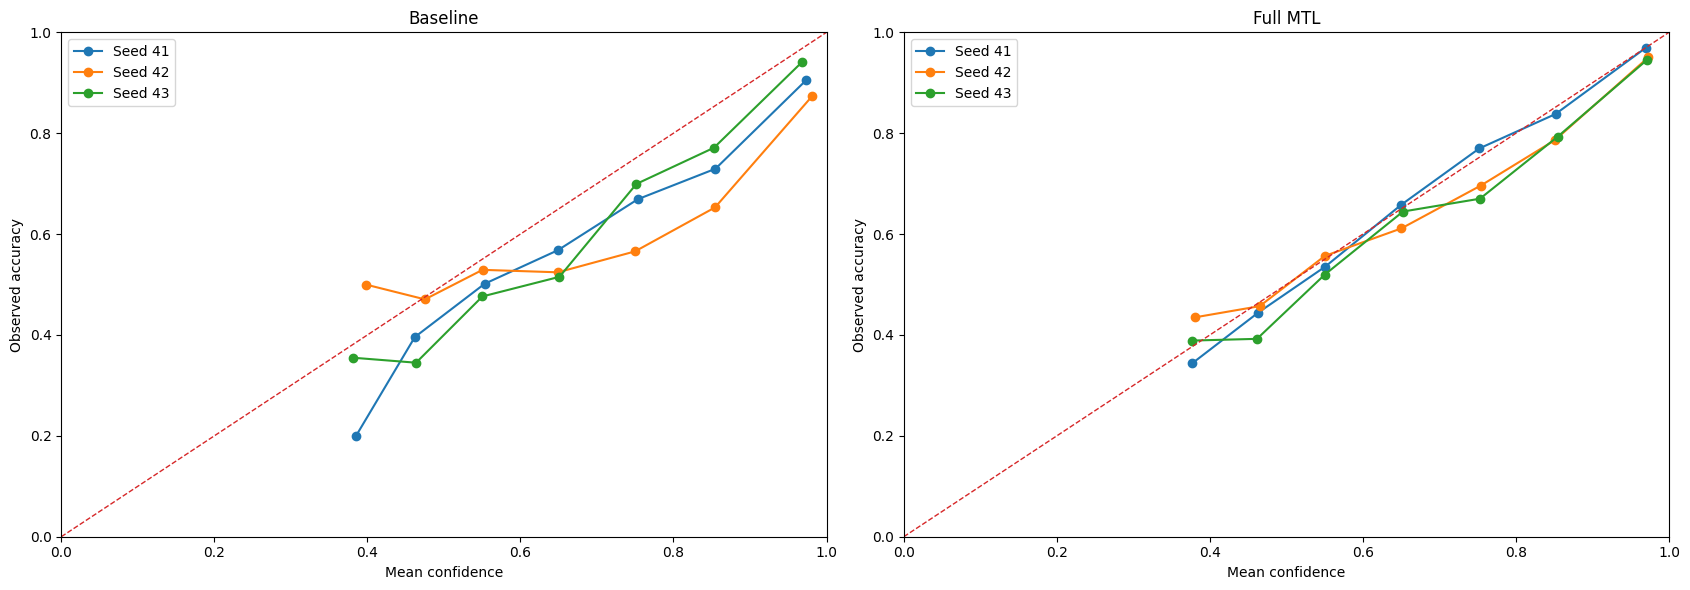

In [34]:
## Plot top-label reliability curves

fig, axes = plt.subplots(1, 2, figsize=(17, 6))


for axis, (model_name, _) in zip(axes, calibration_model_sets):

    for seed in FINAL_TRAIN_SEEDS:

        bin_df = calibration_bins[model_name][seed]
        valid_bins = bin_df["Count"] > 0

        axis.plot(
            bin_df.loc[valid_bins, "Mean confidence"],
            bin_df.loc[valid_bins, "Accuracy"],
            marker="o",
            label=f"Seed {seed}",
        )


    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(model_name)
    axis.set_xlabel("Mean confidence")
    axis.set_ylabel("Observed accuracy")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend()


plt.tight_layout()

CALIBRATION_FIGURE_PATH = (
    EVALUATION_FIGURE_DIR / "isic_three_class_calibration.png"
)

plt.savefig(
    CALIBRATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 6.5 Save the calibration results

The per-run calibration measures and three-seed summary are saved for later reporting.

In [35]:
## Save the calibration results

CALIBRATION_RUN_PATH = (
    EVALUATION_TABLE_DIR / "isic_calibration_by_run.csv"
)

CALIBRATION_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "isic_calibration_summary.csv"
)


calibration_run_df.to_csv(
    CALIBRATION_RUN_PATH,
    index=False,
)

calibration_summary_df.to_csv(
    CALIBRATION_SUMMARY_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Calibration outputs saved':^67}")
print("=" * 67, "\n")

print(f"Run table     : {CALIBRATION_RUN_PATH.name}")
print(f"Summary table : {CALIBRATION_SUMMARY_PATH.name}")
print(f"Figure        : {CALIBRATION_FIGURE_PATH.name}")

                     Calibration outputs saved                     

Run table     : isic_calibration_by_run.csv
Summary table : isic_calibration_summary.csv
Figure        : isic_three_class_calibration.png


## Section 7: Compare the baseline and full multi-task model

The diagnosis-only baseline and full multi-task model are compared across seeds 41, 42 and 43.

This is the main model comparison.

The comparison uses the test results calculated in Sections 3 to 5:

1. 3-class balanced accuracy.
2. 3-class macro AUROC.
3. Malignant vs rest AUROC.
4. Melanoma vs rest AUROC.

For each metric, the mean and sample standard deviation are calculated across the three seeds.

The difference for each matched seed is calculated as Full MTL minus Baseline.

The 90% and 95% sensitivity operating points are compared separately.



### 7.1 Compare the main diagnostic results

The four diagnostic measures are combined into one matched-seed comparison.

In [36]:
## Build the matched-seed comparison

main_comparison_rows = []

metric_sources = [
    (three_class_run_df, "Balanced accuracy", "3-class balanced accuracy"),
    (three_class_run_df, "Macro AUROC", "3-class macro AUROC"),
    (malignant_auc_df, "Test AUROC", "Malignant vs rest AUROC"),
    (melanoma_auc_df, "Test AUROC", "Melanoma vs rest AUROC"),
]


for dataframe, value_column, metric_name in metric_sources:

    paired_df = dataframe.pivot(
        index="Seed",
        columns="Model",
        values=value_column,
    )

    for seed in FINAL_TRAIN_SEEDS:

        baseline_value = float(paired_df.loc[seed, "Baseline"])
        mtl_value = float(paired_df.loc[seed, "Full MTL"])

        main_comparison_rows.append({
            "Metric": metric_name,
            "Seed": int(seed),
            "Baseline": baseline_value,
            "Full MTL": mtl_value,
            "Difference": mtl_value - baseline_value,
        })


main_comparison_by_seed_df = pd.DataFrame(main_comparison_rows)


print("=" * 67)
print(f"{'Matched-seed comparison':^67}")
print("=" * 67, "\n")

display(main_comparison_by_seed_df.round(4))

                      Matched-seed comparison                      



,Metric,Seed,Baseline,Full MTL,Difference
0,3-class balanced accuracy,41,0.7020,0.6903,-0.0117
1,3-class balanced accuracy,42,0.6938,0.7214,0.0276
2,3-class balanced accuracy,43,0.7323,0.6868,-0.0456
3,3-class macro AUROC,41,0.9076,0.9010,-0.0066
4,3-class macro AUROC,42,0.9021,0.9071,0.0050
5,3-class macro AUROC,43,0.8911,0.9047,0.0136
6,Malignant vs rest AUROC,41,0.8818,0.8724,-0.0094
7,Malignant vs rest AUROC,42,0.8860,0.8779,-0.0081
8,Malignant vs rest AUROC,43,0.8454,0.8804,0.0349
9,Melanoma vs rest AUROC,41,0.7994,0.7747,-0.0246


### 7.2 Summarise the diagnostic results

The baseline, full multi-task model and matched-seed differences are summarised across seeds 41, 42 and 43.

In [37]:
## Summarise the diagnostic results

main_comparison_summary_rows = []

for metric_name in main_comparison_by_seed_df["Metric"].unique():

    metric_df = main_comparison_by_seed_df[
        main_comparison_by_seed_df["Metric"] == metric_name
    ]

    main_comparison_summary_rows.append({
        "Metric": metric_name,
        "Baseline mean": float(metric_df["Baseline"].mean()),
        "Baseline SD": float(metric_df["Baseline"].std(ddof=1)),
        "Full MTL mean": float(metric_df["Full MTL"].mean()),
        "Full MTL SD": float(metric_df["Full MTL"].std(ddof=1)),
        "Difference mean": float(metric_df["Difference"].mean()),
        "Difference SD": float(metric_df["Difference"].std(ddof=1)),
    })


main_comparison_summary_df = pd.DataFrame(
    main_comparison_summary_rows
)


print("=" * 67)
print(f"{'Three-seed diagnostic summary':^67}")
print("=" * 67, "\n")

display(main_comparison_summary_df.round(4))

                   Three-seed diagnostic summary                   



,Metric,Baseline mean,Baseline SD,Full MTL mean,Full MTL SD,Difference mean,Difference SD
0,3-class balanced accuracy,0.7094,0.0203,0.6995,0.0190,-0.0099,0.0366
1,3-class macro AUROC,0.9003,0.0084,0.9043,0.0031,0.0040,0.0102
2,Malignant vs rest AUROC,0.8711,0.0223,0.8769,0.0041,0.0058,0.0252
3,Melanoma vs rest AUROC,0.7886,0.0138,0.7858,0.0173,-0.0028,0.0310


### 7.3 Compare the sensitivity operating points

The 90% sensitivity target is the primary operating point and 95% is secondary.

The thresholds were selected on the validation split in Sections 4 and 5 and applied unchanged to the test split.

Test sensitivity and false-positive rate are summarised across the three seeds.

In [38]:
## Combine the operating-point results

malignant_main_df = malignant_operating_df.copy()
malignant_main_df["Evaluation"] = "Malignant vs rest"

melanoma_main_df = melanoma_operating_df.copy()
melanoma_main_df["Evaluation"] = "Melanoma vs rest"


main_operating_by_seed_df = pd.concat(
    [
        malignant_main_df,
        melanoma_main_df,
    ],
    ignore_index=True,
)

main_operating_by_seed_df = main_operating_by_seed_df[
    [
        "Evaluation",
        "Model",
        "Seed",
        "Target sensitivity",
        "Test sensitivity",
        "Test FPR",
    ]
]


print("=" * 67)
print(f"{'Sensitivity operating points':^67}")
print("=" * 67, "\n")

display(main_operating_by_seed_df.round(4))


                   Sensitivity operating points                    



,Evaluation,Model,Seed,Target sensitivity,Test sensitivity,Test FPR
0,Malignant vs rest,Baseline,41,0.90,0.8975,0.3749
1,Malignant vs rest,Baseline,41,0.95,0.9431,0.4724
2,Malignant vs rest,Full MTL,41,0.90,0.9021,0.3548
3,Malignant vs rest,Full MTL,41,0.95,0.9400,0.4617
4,Malignant vs rest,Baseline,42,0.90,0.8952,0.3252
5,Malignant vs rest,Baseline,42,0.95,0.9560,0.4818
6,Malignant vs rest,Full MTL,42,0.90,0.8990,0.3658
7,Malignant vs rest,Full MTL,42,0.95,0.9423,0.4511
8,Malignant vs rest,Baseline,43,0.90,0.8960,0.4412
9,Malignant vs rest,Baseline,43,0.95,0.9453,0.5442


### 7.4 Summarise the sensitivity operating points

Test sensitivity and false-positive rate are summarised using the mean and sample standard deviation across the three seeds.

In [39]:
## Summarise the operating points

main_operating_summary_rows = []

for evaluation_name in [
    "Malignant vs rest",
    "Melanoma vs rest",
]:

    for target in SENSITIVITY_TARGETS:

        for model_name in ["Baseline", "Full MTL"]:

            result_df = main_operating_by_seed_df[
                (main_operating_by_seed_df["Evaluation"] == evaluation_name)
                & (main_operating_by_seed_df["Model"] == model_name)
                & np.isclose(
                    main_operating_by_seed_df["Target sensitivity"],
                    target,
                )
            ]

            main_operating_summary_rows.append({
                "Evaluation": evaluation_name,
                "Target sensitivity": float(target),
                "Model": model_name,
                "Test sensitivity mean": float(
                    result_df["Test sensitivity"].mean()
                ),
                "Test sensitivity SD": float(
                    result_df["Test sensitivity"].std(ddof=1)
                ),
                "Test FPR mean": float(
                    result_df["Test FPR"].mean()
                ),
                "Test FPR SD": float(
                    result_df["Test FPR"].std(ddof=1)
                ),
            })


main_operating_summary_df = pd.DataFrame(
    main_operating_summary_rows
)


print("=" * 67)
print(f"{'Three-seed operating-point summary':^67}")
print("=" * 67, "\n")

display(main_operating_summary_df.round(4))

                Three-seed operating-point summary                 



,Evaluation,Target sensitivity,Model,Test sensitivity mean,Test sensitivity SD,Test FPR mean,Test FPR SD
0,Malignant vs rest,0.90,Baseline,0.8962,0.0012,0.3804,0.0582
1,Malignant vs rest,0.90,Full MTL,0.8967,0.0067,0.3469,0.0239
2,Malignant vs rest,0.95,Baseline,0.9481,0.0069,0.4995,0.0390
3,Malignant vs rest,0.95,Full MTL,0.9441,0.0052,0.4609,0.0095
4,Melanoma vs rest,0.90,Baseline,0.9143,0.0125,0.5131,0.0168
5,Melanoma vs rest,0.90,Full MTL,0.8829,0.0090,0.5131,0.0328
6,Melanoma vs rest,0.95,Baseline,0.9542,0.0098,0.6023,0.0322
7,Melanoma vs rest,0.95,Full MTL,0.9436,0.0080,0.6059,0.0211


### 7.5 Save the main comparison

The per-seed results and three-seed summaries are saved for later reporting.

In [40]:
## Save the main comparison

MAIN_COMPARISON_BY_SEED_PATH = (
    EVALUATION_TABLE_DIR / "main_comparison_by_seed.csv"
)

MAIN_COMPARISON_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "main_comparison_summary.csv"
)

MAIN_OPERATING_BY_SEED_PATH = (
    EVALUATION_TABLE_DIR / "main_operating_by_seed.csv"
)

MAIN_OPERATING_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "main_operating_summary.csv"
)


main_comparison_by_seed_df.to_csv(
    MAIN_COMPARISON_BY_SEED_PATH,
    index=False,
)

main_comparison_summary_df.to_csv(
    MAIN_COMPARISON_SUMMARY_PATH,
    index=False,
)

main_operating_by_seed_df.to_csv(
    MAIN_OPERATING_BY_SEED_PATH,
    index=False,
)

main_operating_summary_df.to_csv(
    MAIN_OPERATING_SUMMARY_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Main comparison outputs saved':^67}")
print("=" * 67, "\n")

print(f"Diagnostic runs    : {MAIN_COMPARISON_BY_SEED_PATH.name}")
print(f"Diagnostic summary : {MAIN_COMPARISON_SUMMARY_PATH.name}")
print(f"Operating runs     : {MAIN_OPERATING_BY_SEED_PATH.name}")
print(f"Operating summary  : {MAIN_OPERATING_SUMMARY_PATH.name}")

                   Main comparison outputs saved                   

Diagnostic runs    : main_comparison_by_seed.csv
Diagnostic summary : main_comparison_summary.csv
Operating runs     : main_operating_by_seed.csv
Operating summary  : main_operating_summary.csv


## Section 8: Leave-one-out ablations

The seven leave-one-out ablations are evaluated using seed 42.

Each run removes one Derm7pt auxiliary task while keeping the other six.

The full multi-task model from seed 42 is used as the reference.

The comparison uses:

1. 3-class balanced accuracy.
2. 3-class macro AUROC.
3. Malignant vs rest AUROC.
4. Melanoma vs rest AUROC.

The ablation results are descriptive because each leave-one-out model is trained using one seed.

### 8.1 Calculate the ablation results

The same diagnostic measures used for the main comparison are calculated for the full multi-task model and each leave-one-out run.

In [41]:
## Calculate ablation diagnostic results

def calculate_ablation_metrics(dataframe):

    y_true = dataframe["true_label"].astype(int).to_numpy()
    y_pred = dataframe["predicted_label"].astype(int).to_numpy()
    probabilities = dataframe[PROBABILITY_COLUMNS].to_numpy(dtype=float)

    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    class_aurocs = []

    for class_index in range(len(CLASS_NAMES)):

        binary_truth = (y_true == class_index).astype(int)

        class_aurocs.append(
            roc_auc_score(
                binary_truth,
                probabilities[:, class_index],
            )
        )

    macro_auroc = float(np.mean(class_aurocs))

    malignant_truth, malignant_scores = get_malignant_binary_data(
        dataframe
    )

    malignant_auroc = roc_auc_score(
        malignant_truth,
        malignant_scores,
    )

    melanoma_truth, melanoma_scores = get_melanoma_binary_data(
        dataframe
    )

    melanoma_auroc = roc_auc_score(
        melanoma_truth,
        melanoma_scores,
    )

    return {
        "3-class balanced accuracy": float(balanced_accuracy),
        "3-class macro AUROC": float(macro_auroc),
        "Malignant vs rest AUROC": float(malignant_auroc),
        "Melanoma vs rest AUROC": float(melanoma_auroc),
    }

In [42]:
## Build the ablation results table

ablation_result_rows = []

full_mtl_seed42_metrics = calculate_ablation_metrics(
    mtl_predictions[ABLATION_SEED]["test"]
)

ablation_result_rows.append({
    "Run": "Full MTL",
    "Removed task": "None",
    **full_mtl_seed42_metrics,
})


for task_name in AUX_TASKS:

    task_metrics = calculate_ablation_metrics(
        ablation_predictions[task_name]["test"]
    )

    ablation_result_rows.append({
        "Run": "Ablation",
        "Removed task": task_name,
        **task_metrics,
    })


ablation_results_df = pd.DataFrame(ablation_result_rows)


print("=" * 67)
print(f"{'Leave-one-out diagnostic results':^67}")
print("=" * 67, "\n")

display(ablation_results_df.round(4))

                 Leave-one-out diagnostic results                  



,Run,Removed task,3-class balanced accuracy,3-class macro AUROC,Malignant vs rest AUROC,Melanoma vs rest AUROC
0,Full MTL,None,0.7214,0.9071,0.8779,0.8057
1,Ablation,pigment_network,0.7086,0.9029,0.8830,0.7881
2,Ablation,blue_whitish_veil,0.6814,0.8932,0.8691,0.7797
3,Ablation,vascular_structures,0.7102,0.9086,0.8842,0.8041
4,Ablation,pigmentation,0.6826,0.9008,0.8864,0.7645
5,Ablation,streaks,0.7074,0.9131,0.8884,0.7623
6,Ablation,dots_and_globules,0.6998,0.9049,0.8855,0.7734
7,Ablation,regression_structures,0.7040,0.9117,0.8912,0.7973


### 8.2 Compare each ablation with the full model

Each leave-one-out result is compared with the full multi-task model from seed 42.

The difference is calculated as:

`Ablation - Full MTL`

A negative value means that the metric was lower when the auxiliary task was removed. A positive value means that the metric was higher.

Because the ablations use one seed, these differences are not treated as stable task-importance rankings.

In [43]:
## Compare each ablation with full MTL seed 42

metric_columns = [
    "3-class balanced accuracy",
    "3-class macro AUROC",
    "Malignant vs rest AUROC",
    "Melanoma vs rest AUROC",
]

full_mtl_values = ablation_results_df.loc[
    ablation_results_df["Run"] == "Full MTL",
    metric_columns,
].iloc[0]

ablation_difference_df = ablation_results_df.loc[
    ablation_results_df["Run"] == "Ablation",
    ["Removed task", *metric_columns],
].copy()


for metric_name in metric_columns:

    ablation_difference_df[f"Difference: {metric_name}"] = (
        ablation_difference_df[metric_name]
        - full_mtl_values[metric_name]
    )


ablation_difference_df = ablation_difference_df[
    [
        "Removed task",
        *[f"Difference: {metric}" for metric in metric_columns],
    ]
]


print("=" * 67)
print(f"{'Difference from full MTL seed 42':^67}")
print("=" * 67, "\n")

display(ablation_difference_df.round(4))

                 Difference from full MTL seed 42                  



,Removed task,Difference: 3-class balanced accuracy,Difference: 3-class macro AUROC,Difference: Malignant vs rest AUROC,Difference: Melanoma vs rest AUROC
1,pigment_network,-0.0128,-0.0042,0.0051,-0.0176
2,blue_whitish_veil,-0.0400,-0.0139,-0.0088,-0.0260
3,vascular_structures,-0.0111,0.0015,0.0063,-0.0016
4,pigmentation,-0.0387,-0.0063,0.0085,-0.0412
5,streaks,-0.0140,0.0060,0.0104,-0.0434
6,dots_and_globules,-0.0216,-0.0022,0.0076,-0.0323
7,regression_structures,-0.0173,0.0046,0.0133,-0.0084


### 8.3 Save the ablation results

The seed 42 diagnostic results and differences from the full multi-task model are saved for later reporting.

In [44]:
## Save the ablation results

ABLATION_RESULTS_PATH = (
    EVALUATION_TABLE_DIR / "ablation_diagnostic_results.csv"
)

ABLATION_DIFFERENCE_PATH = (
    EVALUATION_TABLE_DIR / "ablation_difference_from_full_mtl.csv"
)


ablation_results_df.to_csv(
    ABLATION_RESULTS_PATH,
    index=False,
)

ablation_difference_df.to_csv(
    ABLATION_DIFFERENCE_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Ablation outputs saved':^67}")
print("=" * 67, "\n")

print(f"Diagnostic results : {ABLATION_RESULTS_PATH.name}")
print(f"Full MTL difference: {ABLATION_DIFFERENCE_PATH.name}")

                      Ablation outputs saved                       

Diagnostic results : ablation_diagnostic_results.csv
Full MTL difference: ablation_difference_from_full_mtl.csv


## Section 9: Derm7pt evaluation

Derm7pt is evaluated in two ways.

1. The seven auxiliary heads are evaluated on the held-out Derm7pt test partition.
2. The diagnostic head is evaluated using the grouped Derm7pt diagnosis labels.

The auxiliary evaluation is held-out evaluation, not cross-dataset evaluation, because Derm7pt training images were used during multi-task training.

For the diagnostic evaluation, NEV and SK are mapped to Benign, MEL and BCC are mapped to Malignant, and MISC is excluded.

### 9.1 Evaluate the auxiliary heads

The saved Derm7pt test balanced accuracy is collected for each full multi-task seed.

The results are then summarised across seeds 41, 42 and 43.

In [45]:
## Load Derm7pt auxiliary results

derm7pt_auxiliary_rows = []

for seed in FINAL_TRAIN_SEEDS:

    auxiliary_results = load_json(
        mtl_registry[seed]["derm7pt_auxiliary_metrics"]
    )

    test_metrics = auxiliary_results["test"]

    for task_name in AUX_TASKS:

        derm7pt_auxiliary_rows.append({
            "Seed": int(seed),
            "Task": task_name,
            "Balanced accuracy": float(
                test_metrics[task_name]["balanced_accuracy"]
            ),
            "N": int(test_metrics[task_name]["n"]),
        })


derm7pt_auxiliary_by_seed_df = pd.DataFrame(
    derm7pt_auxiliary_rows
)


print("=" * 67)
print(f"{'Derm7pt auxiliary test results':^67}")
print("=" * 67, "\n")

display(derm7pt_auxiliary_by_seed_df.round(4))

                  Derm7pt auxiliary test results                   



,Seed,Task,Balanced accuracy,N
0,41,pigment_network,0.6342,395
1,41,blue_whitish_veil,0.8646,395
2,41,vascular_structures,0.6363,395
3,41,pigmentation,0.6291,395
4,41,streaks,0.6483,395
5,41,dots_and_globules,0.5531,395
6,41,regression_structures,0.6358,395
7,42,pigment_network,0.6652,395
8,42,blue_whitish_veil,0.8143,395
9,42,vascular_structures,0.5325,395


### 9.2 Summarise the auxiliary results

Balanced accuracy is summarised using the mean and sample standard deviation across the three full multi-task seeds.

In [46]:
## Summarise Derm7pt auxiliary results

derm7pt_auxiliary_summary_rows = []

for task_name in AUX_TASKS:

    task_df = derm7pt_auxiliary_by_seed_df[
        derm7pt_auxiliary_by_seed_df["Task"] == task_name
    ]

    if task_df["N"].nunique() != 1:
        raise ValueError(
            f"Derm7pt test count differs between seeds for {task_name}."
        )

    derm7pt_auxiliary_summary_rows.append({
        "Task": task_name,
        "Balanced accuracy mean": float(
            task_df["Balanced accuracy"].mean()
        ),
        "Balanced accuracy SD": float(
            task_df["Balanced accuracy"].std(ddof=1)
        ),
        "N": int(task_df["N"].iloc[0]),
    })


derm7pt_auxiliary_summary_df = pd.DataFrame(
    derm7pt_auxiliary_summary_rows
)


print("=" * 67)
print(f"{'Derm7pt auxiliary summary':^67}")
print("=" * 67, "\n")

display(derm7pt_auxiliary_summary_df.round(4))

                     Derm7pt auxiliary summary                     



,Task,Balanced accuracy mean,Balanced accuracy SD,N
0,pigment_network,0.6401,0.0227,395
1,blue_whitish_veil,0.8190,0.0434,395
2,vascular_structures,0.5803,0.0524,395
3,pigmentation,0.5919,0.0364,395
4,streaks,0.6271,0.0245,395
5,dots_and_globules,0.5596,0.0081,395
6,regression_structures,0.6889,0.0476,395


### 9.3 Prepare the diagnostic test set

The official Derm7pt test partition is used.

The grouped diagnosis labels are mapped as follows:

1. NEV and SK to Benign.
2. MEL and BCC to Malignant.
3. MISC is excluded.

The mapped subset is then used for the diagnostic evaluation.

In [47]:
## Prepare the Derm7pt diagnostic test set

derm7pt_meta_df = pd.read_csv(DERM7PT_META_CSV)
derm7pt_targets_df = pd.read_csv(DERM7PT_TARGETS_CSV)

derm7pt_test_indexes = (
    pd.read_csv(DERM7PT_TEST_INDEXES)
    .iloc[:, 0]
    .astype(int)
    .tolist()
)

derm7pt_test_df = derm7pt_meta_df.loc[
    derm7pt_test_indexes
].copy()

derm7pt_test_df["metadata_index"] = derm7pt_test_df.index

derm7pt_test_df = derm7pt_test_df.merge(
    derm7pt_targets_df[
        [
            "metadata_index",
            "diagnosis_group",
        ]
    ],
    on="metadata_index",
    how="left",
    validate="one_to_one",
)

In [48]:
## Check the grouped diagnosis labels

EXPECTED_DERM7PT_GROUPS = {
    "NEV",
    "SK",
    "MEL",
    "BCC",
    "MISC",
}

if derm7pt_test_df["diagnosis_group"].isna().any():
    raise ValueError(
        "Derm7pt test diagnosis groups contain missing values."
    )

observed_groups = set(
    derm7pt_test_df["diagnosis_group"].astype(str)
)

unexpected_groups = observed_groups - EXPECTED_DERM7PT_GROUPS

if unexpected_groups:
    raise ValueError(
        f"Unexpected Derm7pt diagnosis groups: "
        f"{sorted(unexpected_groups)}"
    )

In [49]:
## Map the Derm7pt diagnostic labels

DERM7PT_DIAGNOSTIC_MAPPING = {
    "NEV": 0,
    "SK": 0,
    "MEL": 1,
    "BCC": 1,
}

derm7pt_diagnostic_df = (
    derm7pt_test_df[
        derm7pt_test_df["diagnosis_group"].isin(
            DERM7PT_DIAGNOSTIC_MAPPING
        )
    ]
    .copy()
    .reset_index(drop=True)
)

derm7pt_diagnostic_df["binary_label"] = (
    derm7pt_diagnostic_df["diagnosis_group"]
    .map(DERM7PT_DIAGNOSTIC_MAPPING)
    .astype(int)
)

derm7pt_diagnostic_counts_df = (
    derm7pt_diagnostic_df["diagnosis_group"]
    .value_counts()
    .rename_axis("Diagnosis group")
    .reset_index(name="Count")
)

misc_excluded = int(
    (derm7pt_test_df["diagnosis_group"] == "MISC").sum()
)


print("=" * 67)
print(f"{'Derm7pt diagnostic test set':^67}")
print("=" * 67, "\n")

print(f"Original test rows : {len(derm7pt_test_df)}")
print(f"Mapped test rows   : {len(derm7pt_diagnostic_df)}")
print(f"MISC excluded      : {misc_excluded}")
print()

display(derm7pt_diagnostic_counts_df)

                    Derm7pt diagnostic test set                    

Original test rows : 395
Mapped test rows   : 355
MISC excluded      : 40



,Diagnosis group,Count
0,NEV,219
1,MEL,101
2,SK,19
3,BCC,16


### 9.4 Prepare diagnostic inference

The selected baseline and full multi-task checkpoints are applied to the mapped Derm7pt test images.

The same deterministic image preprocessing used during model evaluation is used here.

Only the diagnostic output is required.

In [50]:
## Check checkpoint settings for Derm7pt inference

reference_checkpoint = torch.load(
    baseline_registry[FINAL_TRAIN_SEEDS[0]]["checkpoint_file"],
    map_location="cpu",
    weights_only=False,
)

DERM_MODEL_NAME = reference_checkpoint["model_name"]
DERM_IMAGE_SIZE = int(reference_checkpoint["image_size"])
DERM_CLASS_TO_IDX = reference_checkpoint["class_to_idx"]

DERM_NUM_CLASSES = len(DERM_CLASS_TO_IDX)
MALIGNANT_INDEX = int(DERM_CLASS_TO_IDX["Malignant"])


for registry in [
    baseline_registry,
    mtl_registry,
]:

    for seed in FINAL_TRAIN_SEEDS:

        checkpoint = torch.load(
            registry[seed]["checkpoint_file"],
            map_location="cpu",
            weights_only=False,
        )

        if checkpoint["model_name"] != DERM_MODEL_NAME:
            raise ValueError(
                "Checkpoint model names do not match."
            )

        if int(checkpoint["image_size"]) != DERM_IMAGE_SIZE:
            raise ValueError(
                "Checkpoint image sizes do not match."
            )

        if checkpoint["class_to_idx"] != DERM_CLASS_TO_IDX:
            raise ValueError(
                "Checkpoint class mappings do not match."
            )


In [51]:
## Define Derm7pt evaluation preprocessing

DERM_IMAGENET_MEAN = (0.485, 0.456, 0.406)
DERM_IMAGENET_STD = (0.229, 0.224, 0.225)

derm7pt_eval_transform = transforms.Compose([
    transforms.Resize(
        (DERM_IMAGE_SIZE, DERM_IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=DERM_IMAGENET_MEAN,
        std=DERM_IMAGENET_STD,
    ),
])


print("=" * 67)
print(f"{'Derm7pt inference settings':^67}")
print("=" * 67, "\n")

print(f"Model name : {DERM_MODEL_NAME}")
print(f"Image size : {DERM_IMAGE_SIZE} x {DERM_IMAGE_SIZE}")
print(f"Classes    : {DERM_CLASS_TO_IDX}")

                    Derm7pt inference settings                     

Model name : swin_tiny_patch4_window7_224
Image size : 224 x 224
Classes    : {'Benign': 0, 'Indeterminate': 1, 'Malignant': 2}


#### Create the diagnostic loader

The mapped Derm7pt test images are loaded using the deterministic evaluation transform.

In [52]:
## Create the Derm7pt diagnostic dataset

class Derm7ptDiagnosticDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform):

        self.df = dataframe.copy()
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = self.image_dir / str(row["derm"])

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        label = int(row["binary_label"])

        return image, label

In [53]:
## Create the Derm7pt diagnostic loader

derm7pt_diagnostic_dataset = Derm7ptDiagnosticDataset(
    dataframe=derm7pt_diagnostic_df,
    image_dir=DERM7PT_IMAGE_DIR,
    transform=derm7pt_eval_transform,
)

derm7pt_diagnostic_loader = DataLoader(
    derm7pt_diagnostic_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)


print("=" * 67)
print(f"{'Derm7pt diagnostic loader':^67}")
print("=" * 67, "\n")

print(f"Evaluation images : {len(derm7pt_diagnostic_dataset)}")

                     Derm7pt diagnostic loader                     

Evaluation images : 355


### 9.5 Load the diagnostic models

The saved baseline model is reloaded directly.

For the full multi-task model, only the shared encoder and diagnostic head are required.

In [54]:
## Define the diagnostic-only MTL model

class MTLDiagnosticModel(nn.Module):

    def __init__(self, model_name, num_classes):

        super().__init__()

        self.encoder = timm.create_model(
            model_name,
            pretrained=False,
            num_classes=0,
        )

        self.diagnostic_head = nn.Linear(
            self.encoder.num_features,
            num_classes,
        )

    def forward(self, images):

        features = self.encoder(images)

        return self.diagnostic_head(features)

### 9.6 Evaluate the diagnostic head

Balanced accuracy and AUROC are calculated on the mapped Derm7pt test subset.

`P_Malignant` is used as the continuous score for AUROC.

For balanced accuracy, the original 3-class prediction is treated as positive only when the predicted class is Malignant.

For the full multi-task model, this is held-out Derm7pt diagnostic evaluation but not a fully independent external test because Derm7pt training images contributed auxiliary supervision to the shared encoder.

Validation-selected operating-point thresholds are evaluated separately in Section 9.8.

In [55]:
## Run Derm7pt diagnostic inference

def run_derm7pt_diagnostic_model(model):

    model.eval()

    all_labels = []
    all_scores = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in derm7pt_diagnostic_loader:

            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            predicted_classes = probabilities.argmax(dim=1)
            malignant_scores = probabilities[:, MALIGNANT_INDEX]

            binary_predictions = (
                predicted_classes == MALIGNANT_INDEX
            ).long()

            all_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_scores.extend(
                malignant_scores.cpu().numpy().tolist()
            )

            all_predictions.extend(
                binary_predictions.cpu().numpy().tolist()
            )

    return (
        np.asarray(all_labels, dtype=int),
        np.asarray(all_scores, dtype=float),
        np.asarray(all_predictions, dtype=int),
    )

In [56]:
## Evaluate baseline and full MTL on Derm7pt

derm7pt_diagnostic_rows = []
derm7pt_diagnostic_prediction_tables = []


for model_name, registry in [
    ("Baseline", baseline_registry),
    ("Full MTL", mtl_registry),
]:

    for seed in FINAL_TRAIN_SEEDS:

        checkpoint = torch.load(
            registry[seed]["checkpoint_file"],
            map_location=DEVICE,
            weights_only=False,
        )

        if model_name == "Baseline":

            model = timm.create_model(
                DERM_MODEL_NAME,
                pretrained=False,
                num_classes=DERM_NUM_CLASSES,
            )

            model.load_state_dict(
                checkpoint["model_state_dict"]
            )

        else:

            model = MTLDiagnosticModel(
                model_name=DERM_MODEL_NAME,
                num_classes=DERM_NUM_CLASSES,
            )

            diagnostic_state = {
                key: value
                for key, value in checkpoint["model_state_dict"].items()
                if (
                    key.startswith("encoder.")
                    or key.startswith("diagnostic_head.")
                )
            }

            model.load_state_dict(
                diagnostic_state,
                strict=True,
            )

        model = model.to(DEVICE)

        y_true, scores, y_pred = run_derm7pt_diagnostic_model(
            model
        )

        balanced_accuracy = balanced_accuracy_score(
            y_true,
            y_pred,
        )

        auroc = roc_auc_score(
            y_true,
            scores,
        )

        derm7pt_diagnostic_rows.append({
            "Model": model_name,
            "Seed": int(seed),
            "Balanced accuracy": float(balanced_accuracy),
            "AUROC": float(auroc),
            "N": int(len(y_true)),
        })


        prediction_df = derm7pt_diagnostic_df[
            [
                "metadata_index",
                "diagnosis_group",
                "binary_label",
            ]
        ].copy()

        prediction_df["Model"] = model_name
        prediction_df["Seed"] = int(seed)
        prediction_df["P_Malignant"] = scores
        prediction_df["Predicted malignant"] = y_pred

        derm7pt_diagnostic_prediction_tables.append(
            prediction_df
        )

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


derm7pt_diagnostic_by_seed_df = pd.DataFrame(
    derm7pt_diagnostic_rows
)

derm7pt_diagnostic_predictions_df = pd.concat(
    derm7pt_diagnostic_prediction_tables,
    ignore_index=True,
)


print("=" * 67)
print(f"{'Derm7pt diagnostic results':^67}")
print("=" * 67, "\n")

display(derm7pt_diagnostic_by_seed_df.round(4))

                    Derm7pt diagnostic results                     



,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.7380,0.8211,355
1,Baseline,42,0.6979,0.7855,355
2,Baseline,43,0.7144,0.7862,355
3,Full MTL,41,0.7360,0.8204,355
4,Full MTL,42,0.7623,0.8338,355
5,Full MTL,43,0.6716,0.7899,355


### 9.7 Summarise the diagnostic results

Balanced accuracy and AUROC are summarised across seeds 41, 42 and 43.

In [57]:
## Summarise Derm7pt diagnostic results

derm7pt_diagnostic_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_df = derm7pt_diagnostic_by_seed_df[
        derm7pt_diagnostic_by_seed_df["Model"] == model_name
    ]

    derm7pt_diagnostic_summary_rows.append({
        "Model": model_name,
        "Balanced accuracy mean": float(
            model_df["Balanced accuracy"].mean()
        ),
        "Balanced accuracy SD": float(
            model_df["Balanced accuracy"].std(ddof=1)
        ),
        "AUROC mean": float(
            model_df["AUROC"].mean()
        ),
        "AUROC SD": float(
            model_df["AUROC"].std(ddof=1)
        ),
        "N": int(model_df["N"].iloc[0]),
    })


derm7pt_diagnostic_summary_df = pd.DataFrame(
    derm7pt_diagnostic_summary_rows
)


print("=" * 67)
print(f"{'Derm7pt diagnostic summary':^67}")
print("=" * 67, "\n")

display(derm7pt_diagnostic_summary_df.round(4))

                    Derm7pt diagnostic summary                     



,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.7168,0.0202,0.7976,0.0203,355
1,Full MTL,0.7233,0.0467,0.8147,0.0225,355


### 9.8 Apply the validation-selected operating points

The malignant-versus-rest thresholds selected on the ISIC validation split in Section 4 are applied unchanged to the mapped Derm7pt test subset.

The 90% sensitivity target is primary and 95% is secondary.

No threshold is selected or adjusted using Derm7pt.

The sensitivity, specificity and false-positive rate achieved after transport are reported for each model and seed.

In [58]:
## Apply validation-selected thresholds to an external dataset

def calculate_transported_operating_points(
    prediction_df,
    source_operating_df,
    evaluation_name,
    threshold_source,
):

    operating_rows = []

    for model_name in ["Baseline", "Full MTL"]:

        for seed in FINAL_TRAIN_SEEDS:

            run_df = prediction_df[
                (prediction_df["Model"] == model_name)
                & (prediction_df["Seed"] == seed)
            ]

            y_true = run_df["binary_label"].astype(int).to_numpy()
            scores = run_df["P_Malignant"].astype(float).to_numpy()

            for target in SENSITIVITY_TARGETS:

                source_row = source_operating_df[
                    (source_operating_df["Model"] == model_name)
                    & (source_operating_df["Seed"] == seed)
                    & np.isclose(
                        source_operating_df["Target sensitivity"],
                        target,
                    )
                ].iloc[0]

                threshold = float(source_row["Threshold"])

                external_point = apply_binary_threshold(
                    y_true,
                    scores,
                    threshold,
                )

                operating_rows.append({
                    "Evaluation": evaluation_name,
                    "Model": model_name,
                    "Seed": int(seed),
                    "Target sensitivity": float(target),
                    "Threshold source": threshold_source,
                    "Threshold": threshold,
                    "Validation sensitivity": float(
                        source_row["Validation sensitivity"]
                    ),
                    "Validation specificity": float(
                        source_row["Validation specificity"]
                    ),
                    "External sensitivity": float(
                        external_point["sensitivity"]
                    ),
                    "External specificity": float(
                        external_point["specificity"]
                    ),
                    "External FPR": float(
                        external_point["false_positive_rate"]
                    ),
                    "N": int(len(run_df)),
                })

    return pd.DataFrame(operating_rows)


derm7pt_operating_df = calculate_transported_operating_points(
    prediction_df=derm7pt_diagnostic_predictions_df,
    source_operating_df=malignant_operating_df,
    evaluation_name="Derm7pt",
    threshold_source="ISIC validation, malignant vs rest",
)


print("=" * 67)
print(f"{'Derm7pt transported operating points':^67}")
print("=" * 67, "\n")

display(
    derm7pt_operating_df.round({
        "Target sensitivity": 2,
        "Threshold": 6,
        "Validation sensitivity": 4,
        "Validation specificity": 4,
        "External sensitivity": 4,
        "External specificity": 4,
        "External FPR": 4,
    })
)

               Derm7pt transported operating points                



,Evaluation,Model,Seed,Target sensitivity,Threshold source,Threshold,Validation sensitivity,Validation specificity,External sensitivity,External specificity,External FPR,N
0,Derm7pt,Baseline,41,0.90,"ISIC validation, malignant vs rest",0.211575,0.9007,0.6232,0.7949,0.7143,0.2857,355
1,Derm7pt,Baseline,41,0.95,"ISIC validation, malignant vs rest",0.123313,0.9507,0.5326,0.8718,0.6008,0.3992,355
2,Derm7pt,Baseline,42,0.90,"ISIC validation, malignant vs rest",0.130242,0.9015,0.6805,0.6667,0.7185,0.2815,355
3,Derm7pt,Baseline,42,0.95,"ISIC validation, malignant vs rest",0.035044,0.9507,0.5188,0.8462,0.5378,0.4622,355
4,Derm7pt,Baseline,43,0.90,"ISIC validation, malignant vs rest",0.165345,0.9007,0.5666,0.7949,0.5378,0.4622,355
5,Derm7pt,Baseline,43,0.95,"ISIC validation, malignant vs rest",0.112952,0.9515,0.4599,0.8376,0.3866,0.6134,355
6,Derm7pt,Full MTL,41,0.90,"ISIC validation, malignant vs rest",0.279277,0.9015,0.6477,0.7094,0.7185,0.2815,355
7,Derm7pt,Full MTL,41,0.95,"ISIC validation, malignant vs rest",0.194538,0.9507,0.5453,0.7778,0.6176,0.3824,355
8,Derm7pt,Full MTL,42,0.90,"ISIC validation, malignant vs rest",0.256327,0.9015,0.6564,0.8205,0.6933,0.3067,355
9,Derm7pt,Full MTL,42,0.95,"ISIC validation, malignant vs rest",0.178861,0.9507,0.5611,0.8718,0.6134,0.3866,355


### 9.9 Save the Derm7pt results

The auxiliary, diagnostic and transported operating-point results are saved for later reporting.

In [59]:
## Save Derm7pt evaluation results

DERM7PT_AUX_BY_SEED_PATH = (
    EVALUATION_TABLE_DIR / "derm7pt_auxiliary_by_seed.csv"
)

DERM7PT_AUX_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "derm7pt_auxiliary_summary.csv"
)

DERM7PT_DIAGNOSTIC_BY_SEED_PATH = (
    EVALUATION_TABLE_DIR / "derm7pt_diagnostic_by_seed.csv"
)

DERM7PT_DIAGNOSTIC_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "derm7pt_diagnostic_summary.csv"
)

DERM7PT_OPERATING_PATH = (
    EVALUATION_TABLE_DIR / "derm7pt_transported_operating_points.csv"
)

DERM7PT_DIAGNOSTIC_PREDICTIONS_PATH = (
    EVALUATION_PREDICTION_DIR / "derm7pt_diagnostic_predictions.csv"
)


derm7pt_auxiliary_by_seed_df.to_csv(
    DERM7PT_AUX_BY_SEED_PATH,
    index=False,
)

derm7pt_auxiliary_summary_df.to_csv(
    DERM7PT_AUX_SUMMARY_PATH,
    index=False,
)

derm7pt_diagnostic_by_seed_df.to_csv(
    DERM7PT_DIAGNOSTIC_BY_SEED_PATH,
    index=False,
)

derm7pt_diagnostic_summary_df.to_csv(
    DERM7PT_DIAGNOSTIC_SUMMARY_PATH,
    index=False,
)

derm7pt_operating_df.to_csv(
    DERM7PT_OPERATING_PATH,
    index=False,
)

derm7pt_diagnostic_predictions_df.to_csv(
    DERM7PT_DIAGNOSTIC_PREDICTIONS_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Derm7pt outputs saved':^67}")
print("=" * 67, "\n")

print(f"Auxiliary runs        : {DERM7PT_AUX_BY_SEED_PATH.name}")
print(f"Auxiliary summary     : {DERM7PT_AUX_SUMMARY_PATH.name}")
print(f"Diagnostic runs       : {DERM7PT_DIAGNOSTIC_BY_SEED_PATH.name}")
print(f"Diagnostic summary    : {DERM7PT_DIAGNOSTIC_SUMMARY_PATH.name}")
print(f"Operating points      : {DERM7PT_OPERATING_PATH.name}")
print(f"Diagnostic predictions: {DERM7PT_DIAGNOSTIC_PREDICTIONS_PATH.name}")

                       Derm7pt outputs saved                       

Auxiliary runs        : derm7pt_auxiliary_by_seed.csv
Auxiliary summary     : derm7pt_auxiliary_summary.csv
Diagnostic runs       : derm7pt_diagnostic_by_seed.csv
Diagnostic summary    : derm7pt_diagnostic_summary.csv
Operating points      : derm7pt_transported_operating_points.csv
Diagnostic predictions: derm7pt_diagnostic_predictions.csv


## Section 10: PH2 external evaluation

PH2 is used as an inference-only external diagnostic evaluation.

The 200 PH2 cases are mapped to a binary target:

1. Melanoma is positive.
2. Common nevus is negative.
3. Atypical nevus is negative.

The model score is the diagnostic head's `P_Malignant` output.

`P_Malignant` is a broad malignancy score and is not interpreted as a melanoma-specific probability.

PH2 is not used for training, checkpoint selection or threshold selection.

### 10.1 Load the prepared PH2 data

The prepared PH2 metadata are loaded and checked before inference.

The binary evaluation label is recreated from `Clinical Diagnosis`.

In [60]:
## Load the prepared PH2 data

PH2_PREPARED_CSV = PH2_BASE / "ph2_prepared.csv"

ph2_df = pd.read_csv(PH2_PREPARED_CSV)


if len(ph2_df) != 200:
    raise ValueError(
        f"Expected 200 PH2 cases, found {len(ph2_df)}."
    )


## Remove whitespace retained from the PH2 text metadata.
ph2_df["Name"] = ph2_df["Name"].astype(str).str.strip()

if ph2_df["Name"].duplicated().any():
    raise ValueError("Duplicate PH2 image IDs found.")


ph2_df["Clinical Diagnosis"] = (
    ph2_df["Clinical Diagnosis"].astype(int)
)

expected_ph2_labels = {0, 1, 2}
observed_ph2_labels = set(ph2_df["Clinical Diagnosis"])

if observed_ph2_labels != expected_ph2_labels:
    raise ValueError(
        f"Unexpected PH2 diagnosis labels: "
        f"{sorted(observed_ph2_labels)}"
    )


PH2_DIAGNOSIS_NAMES = {
    0: "Common nevus",
    1: "Atypical nevus",
    2: "Melanoma",
}

ph2_df["Diagnosis"] = (
    ph2_df["Clinical Diagnosis"].map(PH2_DIAGNOSIS_NAMES)
)

ph2_df["binary_label"] = (
    ph2_df["Clinical Diagnosis"].eq(2).astype(int)
)


ph2_counts_df = (
    ph2_df["Diagnosis"]
    .value_counts()
    .reindex([
        "Common nevus",
        "Atypical nevus",
        "Melanoma",
    ])
    .rename_axis("Diagnosis")
    .reset_index(name="Count")
)


print("=" * 67)
print(f"{'PH2 external evaluation set':^67}")
print("=" * 67, "\n")

print(f"Total cases : {len(ph2_df)}")
print(f"Melanoma    : {int(ph2_df['binary_label'].sum())}")
print(f"Non-melanoma: {int((ph2_df['binary_label'] == 0).sum())}")
print()

display(ph2_counts_df)

                    PH2 external evaluation set                    

Total cases : 200
Melanoma    : 40
Non-melanoma: 160



,Diagnosis,Count
0,Common nevus,80
1,Atypical nevus,80
2,Melanoma,40


### 10.2 Check the PH2 images

The dermoscopic image path is reconstructed from each PH2 image ID.

All 200 images are checked before the evaluation loader is created.

In [61]:
## Check the PH2 image paths

def get_ph2_image_path(image_name):

    image_name = str(image_name)

    image_folder = (
        PH2_IMAGE_DIR
        / image_name
        / f"{image_name}_Dermoscopic_Image"
    )

    if not image_folder.is_dir():
        raise FileNotFoundError(
            f"Missing PH2 image folder: {image_folder}"
        )

    image_files = [
        path
        for path in image_folder.iterdir()
        if path.is_file()
    ]

    if len(image_files) != 1:
        raise ValueError(
            f"Expected one dermoscopic image for {image_name}, "
            f"found {len(image_files)}."
        )

    return image_files[0]


ph2_df["image_path"] = ph2_df["Name"].map(
    get_ph2_image_path
)


print("=" * 67)
print(f"{'PH2 image check':^67}")
print("=" * 67, "\n")

print(f"Images found : {len(ph2_df)}")

                          PH2 image check                          

Images found : 200


### 10.3 Prepare PH2 inference

The same model settings and deterministic evaluation preprocessing used for the Derm7pt diagnostic inference are reused for PH2.

In [62]:
## Prepare PH2 inference settings

PH2_MODEL_NAME = DERM_MODEL_NAME
PH2_IMAGE_SIZE = DERM_IMAGE_SIZE
PH2_CLASS_TO_IDX = DERM_CLASS_TO_IDX

PH2_NUM_CLASSES = DERM_NUM_CLASSES
PH2_MALIGNANT_INDEX = MALIGNANT_INDEX

ph2_eval_transform = derm7pt_eval_transform


print("=" * 67)
print(f"{'PH2 inference settings':^67}")
print("=" * 67, "\n")

print(f"Model name : {PH2_MODEL_NAME}")
print(f"Image size : {PH2_IMAGE_SIZE} x {PH2_IMAGE_SIZE}")
print(f"Classes    : {PH2_CLASS_TO_IDX}")

                      PH2 inference settings                       

Model name : swin_tiny_patch4_window7_224
Image size : 224 x 224
Classes    : {'Benign': 0, 'Indeterminate': 1, 'Malignant': 2}


### 10.4 Create the PH2 evaluation loader

The PH2 images are loaded using the deterministic evaluation transform.

Melanoma is coded as 1 and both nevus groups are coded as 0.

In [63]:
## Create the PH2 evaluation loader

class PH2DiagnosticDataset(Dataset):

    def __init__(self, dataframe, transform):

        self.df = dataframe.copy().reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = self.transform(image)

        label = int(row["binary_label"])

        return image, label


ph2_dataset = PH2DiagnosticDataset(
    dataframe=ph2_df,
    transform=ph2_eval_transform,
)

ph2_loader = DataLoader(
    ph2_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)


print("=" * 67)
print(f"{'PH2 evaluation loader':^67}")
print("=" * 67, "\n")

print(f"Evaluation images : {len(ph2_dataset)}")

                       PH2 evaluation loader                       

Evaluation images : 200


### 10.5 Run PH2 inference

The baseline and full multi-task checkpoints are evaluated for seeds 41, 42 and 43.

`P_Malignant` is used as the continuous score for melanoma vs nevus AUROC.

For balanced accuracy, the original 3-class prediction is treated as positive only when the predicted class is Malignant.

Validation-selected operating-point thresholds are evaluated separately in Section 10.8.


In [64]:
## Run PH2 diagnostic inference

def run_ph2_diagnostic_model(model):

    model.eval()

    all_labels = []
    all_scores = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in ph2_loader:

            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            predicted_classes = probabilities.argmax(dim=1)
            malignant_scores = probabilities[:, PH2_MALIGNANT_INDEX]

            binary_predictions = (
                predicted_classes == PH2_MALIGNANT_INDEX
            ).long()

            all_labels.extend(
                labels.numpy().tolist()
            )

            all_scores.extend(
                malignant_scores.cpu().numpy().tolist()
            )

            all_predictions.extend(
                binary_predictions.cpu().numpy().tolist()
            )

    return (
        np.asarray(all_labels, dtype=int),
        np.asarray(all_scores, dtype=float),
        np.asarray(all_predictions, dtype=int),
    )

In [65]:
## Evaluate baseline and full MTL on PH2

ph2_result_rows = []
ph2_prediction_tables = []


for model_name, registry in [
    ("Baseline", baseline_registry),
    ("Full MTL", mtl_registry),
]:

    for seed in FINAL_TRAIN_SEEDS:

        print(f"Running {model_name}, seed {seed}...")

        checkpoint = torch.load(
            registry[seed]["checkpoint_file"],
            map_location=DEVICE,
            weights_only=False,
        )

        if model_name == "Baseline":

            model = timm.create_model(
                PH2_MODEL_NAME,
                pretrained=False,
                num_classes=PH2_NUM_CLASSES,
            )

            model.load_state_dict(
                checkpoint["model_state_dict"]
            )

        else:

            model = MTLDiagnosticModel(
                model_name=PH2_MODEL_NAME,
                num_classes=PH2_NUM_CLASSES,
            )

            diagnostic_state = {
                key: value
                for key, value in checkpoint["model_state_dict"].items()
                if (
                    key.startswith("encoder.")
                    or key.startswith("diagnostic_head.")
                )
            }

            model.load_state_dict(
                diagnostic_state,
                strict=True,
            )


        model = model.to(DEVICE)

        y_true, scores, y_pred = run_ph2_diagnostic_model(
            model
        )

        balanced_accuracy = balanced_accuracy_score(
            y_true,
            y_pred,
        )

        auroc = roc_auc_score(
            y_true,
            scores,
        )


        ph2_result_rows.append({
            "Model": model_name,
            "Seed": int(seed),
            "Balanced accuracy": float(balanced_accuracy),
            "AUROC": float(auroc),
            "N": int(len(y_true)),
        })


        prediction_df = ph2_df[
            [
                "Name",
                "Clinical Diagnosis",
                "Diagnosis",
            ]
        ].copy()

        prediction_df["binary_label"] = y_true
        prediction_df["Model"] = model_name
        prediction_df["Seed"] = int(seed)
        prediction_df["P_Malignant"] = scores
        prediction_df["Predicted malignant"] = y_pred

        ph2_prediction_tables.append(
            prediction_df
        )


        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


ph2_by_seed_df = pd.DataFrame(ph2_result_rows)

ph2_predictions_df = pd.concat(
    ph2_prediction_tables,
    ignore_index=True,
)


print()
print("=" * 67)
print(f"{'PH2 diagnostic results':^67}")
print("=" * 67, "\n")

display(ph2_by_seed_df.round(4))

Running Baseline, seed 41...
Running Baseline, seed 42...
Running Baseline, seed 43...
Running Full MTL, seed 41...
Running Full MTL, seed 42...
Running Full MTL, seed 43...

                      PH2 diagnostic results                       



,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.8406,0.8912,200
1,Baseline,42,0.8031,0.8841,200
2,Baseline,43,0.6875,0.7584,200
3,Full MTL,41,0.6906,0.8841,200
4,Full MTL,42,0.8219,0.8838,200
5,Full MTL,43,0.6469,0.8267,200


### 10.6 Summarise the PH2 results

Balanced accuracy and AUROC are summarised across seeds 41, 42 and 43.

In [66]:
## Summarise PH2 diagnostic results

ph2_summary_rows = []

for model_name in ["Baseline", "Full MTL"]:

    model_df = ph2_by_seed_df[
        ph2_by_seed_df["Model"] == model_name
    ]

    ph2_summary_rows.append({
        "Model": model_name,
        "Balanced accuracy mean": float(
            model_df["Balanced accuracy"].mean()
        ),
        "Balanced accuracy SD": float(
            model_df["Balanced accuracy"].std(ddof=1)
        ),
        "AUROC mean": float(
            model_df["AUROC"].mean()
        ),
        "AUROC SD": float(
            model_df["AUROC"].std(ddof=1)
        ),
        "N": len(ph2_df),
    })


ph2_summary_df = pd.DataFrame(ph2_summary_rows)


print("=" * 67)
print(f"{'PH2 three-seed summary':^67}")
print("=" * 67, "\n")

display(ph2_summary_df.round(4))

                      PH2 three-seed summary                       



,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.7771,0.0798,0.8446,0.0747,200
1,Full MTL,0.7198,0.0911,0.8648,0.0330,200


### 10.7 Plot the PH2 ROC curves

The full PH2 ROC curves are shown for the three baseline and full multi-task seeds.

The score is the broad `P_Malignant` output and the positive class is melanoma.

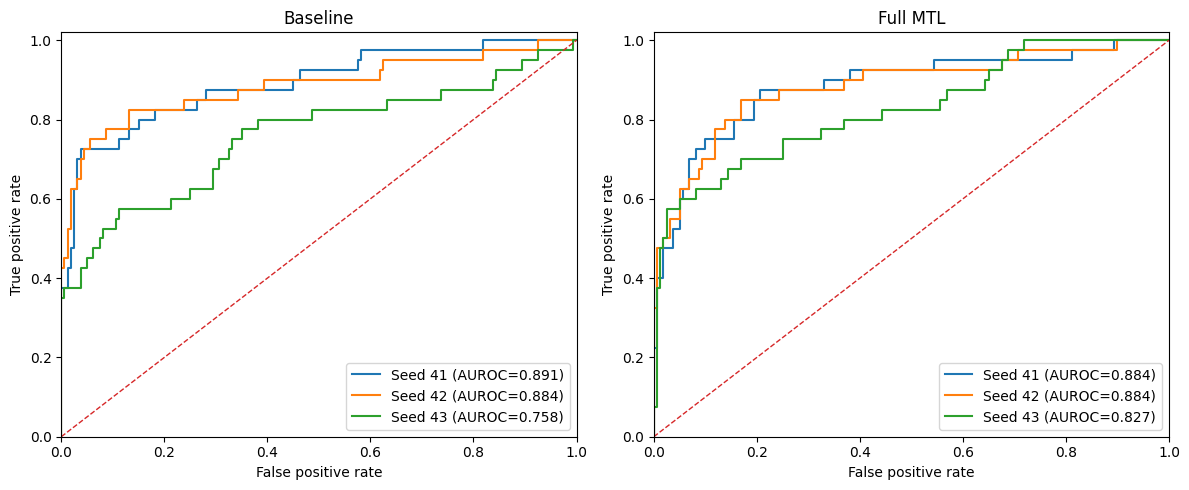

In [67]:
## Plot PH2 ROC curves

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for axis, model_name in zip(
    axes,
    ["Baseline", "Full MTL"],
):

    for seed in FINAL_TRAIN_SEEDS:

        run_df = ph2_predictions_df[
            (ph2_predictions_df["Model"] == model_name)
            & (ph2_predictions_df["Seed"] == seed)
        ]

        fpr, tpr, _ = roc_curve(
            run_df["binary_label"],
            run_df["P_Malignant"],
        )

        auroc = ph2_by_seed_df.loc[
            (ph2_by_seed_df["Model"] == model_name)
            & (ph2_by_seed_df["Seed"] == seed),
            "AUROC",
        ].iloc[0]

        axis.plot(
            fpr,
            tpr,
            label=f"Seed {seed} (AUROC={auroc:.3f})",
        )


    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(model_name)
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.legend()


plt.tight_layout()

PH2_ROC_FIGURE_PATH = (
    EVALUATION_FIGURE_DIR / "ph2_roc_curves.png"
)

plt.savefig(
    PH2_ROC_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 10.8 Apply the validation-selected operating points

The melanoma-versus-rest thresholds selected on the ISIC validation split in Section 5 are applied unchanged to PH2.

The 90% sensitivity target is primary and 95% is secondary.

No threshold is selected or adjusted using PH2.

The sensitivity, specificity and false-positive rate achieved after transport are reported for each model and seed.

In [68]:
## Apply validation-selected thresholds to PH2

ph2_operating_df = calculate_transported_operating_points(
    prediction_df=ph2_predictions_df,
    source_operating_df=melanoma_operating_df,
    evaluation_name="PH2",
    threshold_source="ISIC validation, melanoma vs rest",
)


print("=" * 67)
print(f"{'PH2 transported operating points':^67}")
print("=" * 67, "\n")

display(
    ph2_operating_df.round({
        "Target sensitivity": 2,
        "Threshold": 6,
        "Validation sensitivity": 4,
        "Validation specificity": 4,
        "External sensitivity": 4,
        "External specificity": 4,
        "External FPR": 4,
    })
)

                 PH2 transported operating points                  



,Evaluation,Model,Seed,Target sensitivity,Threshold source,Threshold,Validation sensitivity,Validation specificity,External sensitivity,External specificity,External FPR,N
0,PH2,Baseline,41,0.90,"ISIC validation, melanoma vs rest",0.184711,0.9009,0.4997,0.800,0.8188,0.1813,200
1,PH2,Baseline,41,0.95,"ISIC validation, melanoma vs rest",0.116529,0.9504,0.4318,0.850,0.7375,0.2625,200
2,PH2,Baseline,42,0.90,"ISIC validation, melanoma vs rest",0.071071,0.9009,0.5010,0.825,0.8125,0.1875,200
3,PH2,Baseline,42,0.95,"ISIC validation, melanoma vs rest",0.027531,0.9504,0.4049,0.875,0.6438,0.3562,200
4,PH2,Baseline,43,0.90,"ISIC validation, melanoma vs rest",0.163745,0.9009,0.4750,0.625,0.7125,0.2875,200
5,PH2,Baseline,43,0.95,"ISIC validation, melanoma vs rest",0.106168,0.9504,0.3655,0.800,0.5938,0.4062,200
6,PH2,Full MTL,41,0.90,"ISIC validation, melanoma vs rest",0.215192,0.9009,0.4680,0.750,0.8625,0.1375,200
7,PH2,Full MTL,41,0.95,"ISIC validation, melanoma vs rest",0.147424,0.9504,0.3850,0.875,0.7500,0.2500,200
8,PH2,Full MTL,42,0.90,"ISIC validation, melanoma vs rest",0.255500,0.9009,0.5490,0.875,0.6688,0.3313,200
9,PH2,Full MTL,42,0.95,"ISIC validation, melanoma vs rest",0.153625,0.9504,0.4302,0.925,0.4750,0.5250,200


### 10.9 Save the PH2 results

The PH2 run-level results, summary, transported operating points, predictions and ROC figure are saved for later reporting.

In [69]:

## Save the PH2 results

PH2_BY_SEED_PATH = (
    EVALUATION_TABLE_DIR / "ph2_diagnostic_by_seed.csv"
)

PH2_SUMMARY_PATH = (
    EVALUATION_TABLE_DIR / "ph2_diagnostic_summary.csv"
)

PH2_OPERATING_PATH = (
    EVALUATION_TABLE_DIR / "ph2_transported_operating_points.csv"
)

PH2_PREDICTIONS_PATH = (
    EVALUATION_PREDICTION_DIR / "ph2_diagnostic_predictions.csv"
)


ph2_by_seed_df.to_csv(
    PH2_BY_SEED_PATH,
    index=False,
)

ph2_summary_df.to_csv(
    PH2_SUMMARY_PATH,
    index=False,
)

ph2_operating_df.to_csv(
    PH2_OPERATING_PATH,
    index=False,
)

ph2_predictions_df.to_csv(
    PH2_PREDICTIONS_PATH,
    index=False,
)


print("=" * 67)
print(f"{'PH2 outputs saved':^67}")
print("=" * 67, "\n")

print(f"Diagnostic runs       : {PH2_BY_SEED_PATH.name}")
print(f"Diagnostic summary    : {PH2_SUMMARY_PATH.name}")
print(f"Operating points      : {PH2_OPERATING_PATH.name}")
print(f"Diagnostic predictions: {PH2_PREDICTIONS_PATH.name}")
print(f"ROC figure            : {PH2_ROC_FIGURE_PATH.name}")

                         PH2 outputs saved                         

Diagnostic runs       : ph2_diagnostic_by_seed.csv
Diagnostic summary    : ph2_diagnostic_summary.csv
Operating points      : ph2_transported_operating_points.csv
Diagnostic predictions: ph2_diagnostic_predictions.csv
ROC figure            : ph2_roc_curves.png


## Section 11: Final checks

Two final checks are performed before completing the evaluation.

1. The expected evaluation outputs must exist and be non-empty.
2. The experiment registry must contain only the final v2 runs.

### 11.1 Check the final evaluation outputs

The expected tables, prediction files and figures produced by this notebook are checked for missing or empty files.

In [70]:
## Check the final evaluation outputs

EXPECTED_EVALUATION_OUTPUTS = [
    CONFUSION_FIGURE_PATH,
    MALIGNANT_ROC_FIGURE_PATH,
    MELANOMA_ROC_FIGURE_PATH,
    CALIBRATION_FIGURE_PATH,
    CALIBRATION_RUN_PATH,
    CALIBRATION_SUMMARY_PATH,
    MAIN_COMPARISON_BY_SEED_PATH,
    MAIN_COMPARISON_SUMMARY_PATH,
    MAIN_OPERATING_BY_SEED_PATH,
    MAIN_OPERATING_SUMMARY_PATH,
    ABLATION_RESULTS_PATH,
    ABLATION_DIFFERENCE_PATH,
    DERM7PT_AUX_BY_SEED_PATH,
    DERM7PT_AUX_SUMMARY_PATH,
    DERM7PT_DIAGNOSTIC_BY_SEED_PATH,
    DERM7PT_DIAGNOSTIC_SUMMARY_PATH,
    DERM7PT_OPERATING_PATH,
    DERM7PT_DIAGNOSTIC_PREDICTIONS_PATH,
    PH2_BY_SEED_PATH,
    PH2_SUMMARY_PATH,
    PH2_OPERATING_PATH,
    PH2_PREDICTIONS_PATH,
    PH2_ROC_FIGURE_PATH,
]


missing_outputs = [
    path
    for path in EXPECTED_EVALUATION_OUTPUTS
    if not path.is_file()
]

if missing_outputs:
    raise FileNotFoundError(
        f"Missing evaluation outputs: {missing_outputs}"
    )


empty_outputs = [
    path
    for path in EXPECTED_EVALUATION_OUTPUTS
    if path.stat().st_size == 0
]

if empty_outputs:
    raise ValueError(
        f"Empty evaluation outputs: {empty_outputs}"
    )


print("=" * 67)
print(f"{'Final evaluation outputs':^67}")
print("=" * 67, "\n")

print(f"Expected files : {len(EXPECTED_EVALUATION_OUTPUTS)}")
print(f"Missing files  : {len(missing_outputs)}")
print(f"Empty files    : {len(empty_outputs)}")
print()

for path in EXPECTED_EVALUATION_OUTPUTS:
    print(path.relative_to(EVALUATION_ROOT))






                     Final evaluation outputs                      

Expected files : 23
Missing files  : 0
Empty files    : 0

figures/isic_three_class_confusion_matrices.png
figures/isic_malignant_vs_rest_roc.png
figures/isic_melanoma_vs_rest_roc.png
figures/isic_three_class_calibration.png
tables/isic_calibration_by_run.csv
tables/isic_calibration_summary.csv
tables/main_comparison_by_seed.csv
tables/main_comparison_summary.csv
tables/main_operating_by_seed.csv
tables/main_operating_summary.csv
tables/ablation_diagnostic_results.csv
tables/ablation_difference_from_full_mtl.csv
tables/derm7pt_auxiliary_by_seed.csv
tables/derm7pt_auxiliary_summary.csv
tables/derm7pt_diagnostic_by_seed.csv
tables/derm7pt_diagnostic_summary.csv
tables/derm7pt_transported_operating_points.csv
predictions/derm7pt_diagnostic_predictions.csv
tables/ph2_diagnostic_by_seed.csv
tables/ph2_diagnostic_summary.csv
tables/ph2_transported_operating_points.csv
predictions/ph2_diagnostic_predictions.csv
figures/ph2_r

### 11.2 Confirm the final experiment registry

The final evaluation must reference the v2 baseline, full multi-task and leave-one-out ablation runs defined in Section 1.

In [71]:
## Confirm the final experiment registry

registered_run_names = [
    *BASELINE_RUN_NAMES.values(),
    *MTL_RUN_NAMES.values(),
    *ABLATION_RUN_NAMES.values(),
]


if len(registered_run_names) != 13:
    raise ValueError(
        f"Expected 13 registered runs, found {len(registered_run_names)}."
    )


baseline_v2 = all(
    run_name.startswith("baseline_final_v2_seed_")
    for run_name in BASELINE_RUN_NAMES.values()
)

mtl_v2 = all(
    run_name.startswith("mtl_final_v2_seed_")
    for run_name in MTL_RUN_NAMES.values()
)

ablation_v2 = all(
    run_name.startswith("mtl_ablation_v2_no_")
    for run_name in ABLATION_RUN_NAMES.values()
)


if not (baseline_v2 and mtl_v2 and ablation_v2):
    raise ValueError(
        "The experiment registry contains non-v2 run names."
    )


print("=" * 67)
print(f"{'Final experiment registry':^67}")
print("=" * 67, "\n")

print(f"Registered runs : {len(registered_run_names)}")
print("Status          : Final v2")

                     Final experiment registry                     

Registered runs : 13
Status          : Final v2


## Final output structure

The completed evaluation outputs are organised as:

```text
FinalEvaluation_Folder/
├── figures/
├── predictions/
└── tables/